# PROJET 7 : IMPLEMENTEZ UN MODELE DE SCORING

## Livrable 2 : Notebook Modélisation

### Contexte Métier

La société financière "Prêt à dépenser" veut un algorithme de scoring pour estimer la probabilité qu'un client fasse défaut sur son crédit. L'enjeu : détecter les mauvais payeurs (Target = 1) sans trop pénaliser les bons dossiers.

### Ce qu'on fait dans ce notebook

- On met en place le tracking MLflow pour garder une trace de chaque expérience
- On définit une métrique métier custom (les FN coûtent plus cher que les FP dans le contexte bancaire)
- On part d'une Baseline naïve (Dummy) pour avoir un score de référence, puis on monte en complexité

On commence avec les données brutes pour valider le pipeline technique. Le Feature Engineering Kaggle viendra après.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

import mlflow
import mlflow.sklearn

from lightgbm import LGBMClassifier

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# chemin vers mlruns à la racine du projet (dossier parent de notebooks/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
MLRUNS_PATH  = os.path.join(PROJECT_ROOT, "mlruns")
os.makedirs(MLRUNS_PATH, exist_ok=True)

mlflow.set_tracking_uri(f"file:///{MLRUNS_PATH.replace(os.sep, '/')}")

experiment_name = "P7_Credit_Scoring_Baseline"
mlflow.set_experiment(experiment_name)

print(f"MLflow configuré — Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Expérience : {experiment_name}")
print(f"\nPour lancer l'UI : mlflow ui --backend-store-uri \"{MLRUNS_PATH}\"")
print(f"Puis ouvrir : http://127.0.0.1:5000")

MLflow configuré — Tracking URI : file:///c:/Users/BFXD8246/Documents/formation_openclassrooms/7_Projet7/mlruns
Expérience : P7_Credit_Scoring_Baseline

Pour lancer l'UI : mlflow ui --backend-store-uri "c:\Users\BFXD8246\Documents\formation_openclassrooms\7_Projet7\mlruns"
Puis ouvrir : http://127.0.0.1:5000


## 1. Chargement et Préparation des Données

On charge `application_train.csv` et on fusionne les tables annexes (bureau, previous, installments). Le Feature Engineering complet viendra après la Baseline.

### 1.1 Nettoyage des Données 

Pour cette première passe, on fait un nettoyage assez brutal :
- On ne garde que les colonnes numériques (pas d'encodage catégoriel pour l'instant)
- On supprime les lignes avec des NaN (on fera de l'imputation plus tard)

C'est du "Quick & Dirty" assumé — l'idée c'est juste d'avoir un dataset propre pour la Baseline.

On en profite pour regarder la répartition de la Target et confirmer le déséquilibre des classes.

Chargement depuis : ../data/
  Base Application : (307511, 122)
  + Bureau fusionné : (307511, 182)
  + Previous fusionné : (307511, 239)
  + Installments fusionné : (307511, 263)

Visualisation du déséquilibre des classes...


<Figure size 640x480 with 0 Axes>

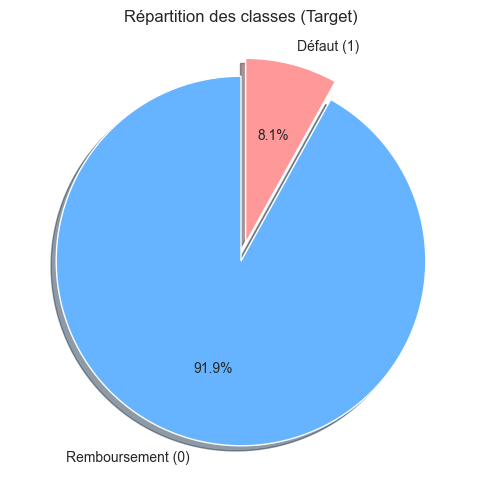

263 colonnes récupérées après fusion.


In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
import os

def load_and_merge_data(data_path='../data/'):
    print(f"Chargement depuis : {data_path}")
    
    if not os.path.exists(data_path + 'application_train.csv'):
        print(f"ERREUR : application_train.csv introuvable dans {data_path}")
        return None

    df = pd.read_csv(data_path + 'application_train.csv')
    print(f"  Base Application : {df.shape}")

    try:
        bureau = pd.read_csv(data_path + 'bureau.csv')
        bb = pd.read_csv(data_path + 'bureau_balance.csv')
        
        bb_num = bb.select_dtypes(include=[np.number])
        bb_agg = bb_num.groupby('SK_ID_BUREAU').agg(['min', 'max', 'size'])
        bb_agg.columns = ['_'.join(col).upper() for col in bb_agg.columns]
        bureau = bureau.join(bb_agg, how='left', on='SK_ID_BUREAU')
        
        bureau_num = bureau.select_dtypes(include=[np.number])
        bureau_agg = bureau_num.drop(columns=['SK_ID_BUREAU'], errors='ignore').groupby('SK_ID_CURR').agg(['min', 'max', 'mean', 'sum'])
        bureau_agg.columns = ['BURO_' + '_'.join(col).upper() for col in bureau_agg.columns]
        
        df = df.join(bureau_agg, how='left', on='SK_ID_CURR')
        print(f"  + Bureau fusionné : {df.shape}")
        
        del bureau, bb, bb_agg, bureau_agg, bureau_num, bb_num
        gc.collect()
    except Exception as e:
        print(f"  Bureau non chargé ({e})")

    try:
        prev = pd.read_csv(data_path + 'previous_application.csv')
        
        prev_num = prev.select_dtypes(include=[np.number])
        prev_agg = prev_num.drop(columns=['SK_ID_PREV'], errors='ignore').groupby('SK_ID_CURR').agg(['mean', 'max', 'size'])
        prev_agg.columns = ['PREV_' + '_'.join(col).upper() for col in prev_agg.columns]
        
        df = df.join(prev_agg, how='left', on='SK_ID_CURR')
        print(f"  + Previous fusionné : {df.shape}")
        del prev, prev_agg, prev_num
        gc.collect()
    except Exception as e:
        print(f"  Previous non chargé ({e})")

    try:
        ins = pd.read_csv(data_path + 'installments_payments.csv')
        ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
        ins['DPD'] = (ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']).clip(lower=0)
        
        ins_num = ins.select_dtypes(include=[np.number])
        ins_agg = ins_num.drop(columns=['SK_ID_PREV'], errors='ignore').groupby('SK_ID_CURR').agg(['mean', 'max', 'sum'])
        ins_agg.columns = ['INSTAL_' + '_'.join(col).upper() for col in ins_agg.columns]
        
        df = df.join(ins_agg, how='left', on='SK_ID_CURR')
        print(f"  + Installments fusionné : {df.shape}")
        del ins, ins_agg, ins_num
        gc.collect()
    except Exception as e:
        print(f"  Installments non chargé ({e})")

    return df

df = load_and_merge_data('../data/')

if df is not None:
    print(f"\nVisualisation du déséquilibre des classes...")
    plt.figure(figsize=(6, 6))
    vals = df['TARGET'].value_counts()
    colors = ['#66b3ff', '#ff9999'] 
    plt.pie(vals, labels=['Remboursement (0)', 'Défaut (1)'], autopct='%1.1f%%', 
            startangle=90, colors=colors, explode=(0, 0.1), shadow=True)
    plt.title('Répartition des classes (Target)')
    plt.show()
    
    if df.shape[1] > 200:
        print(f"{df.shape[1]} colonnes récupérées après fusion.")

## 1.bis — Analyse Exploratoire (EDA)

Avant de modéliser, on regarde ce qu'on a dans les données : valeurs manquantes, déséquilibre des classes, distributions des variables clés, et corrélations avec la cible.

  Lignes   :    307,511
  Colonnes :        263
  Ratio de défaut (TARGET=1) : 8.07%

📊 1. VALEURS MANQUANTES


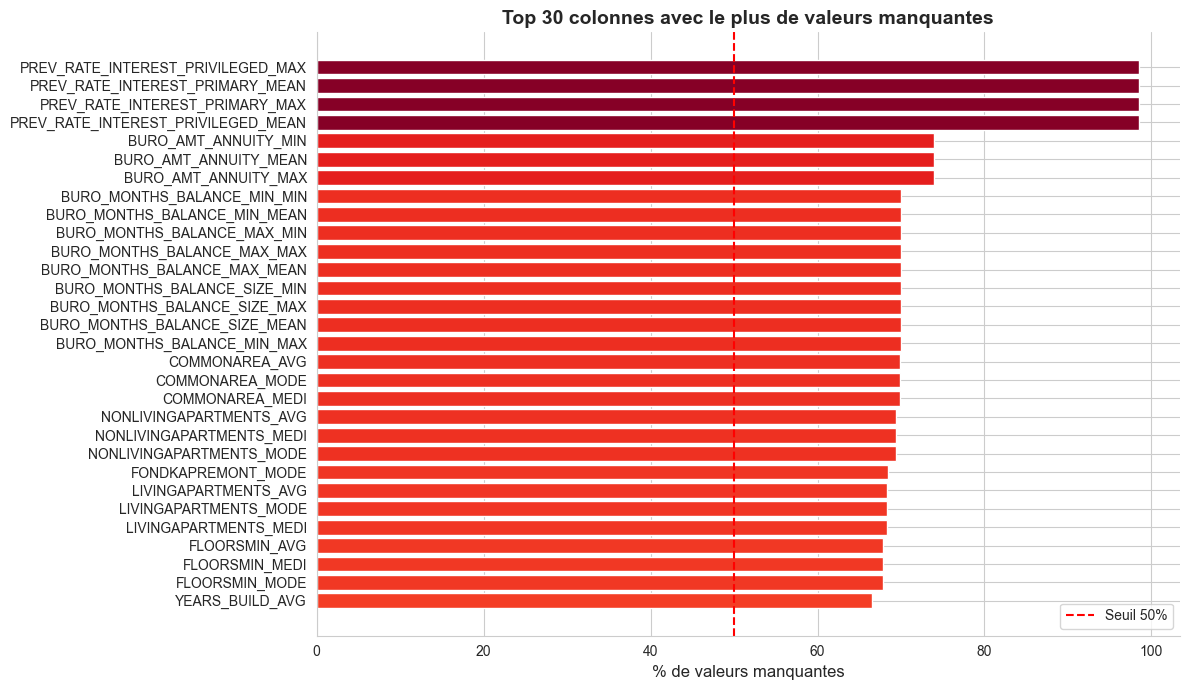

   → 57 colonnes ont plus de 50% de valeurs manquantes.


In [108]:
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print(f"  Lignes   : {df.shape[0]:>10,}")
print(f"  Colonnes : {df.shape[1]:>10,}")
print(f"  Ratio de défaut (TARGET=1) : {df['TARGET'].mean():.2%}")
print("=" * 60)

print("\n📊 1. VALEURS MANQUANTES")

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_top = missing_pct[missing_pct > 0].head(30)

fig, ax = plt.subplots(figsize=(12, 7))
norm_vals = missing_top.values[::-1] / 100
colors_miss = plt.cm.YlOrRd(norm_vals)
ax.barh(missing_top.index[::-1], missing_top.values[::-1], color=colors_miss)
ax.set_xlabel('% de valeurs manquantes', fontsize=12)
ax.set_title('Top 30 colonnes avec le plus de valeurs manquantes', fontsize=14, fontweight='bold')
ax.axvline(50, color='red', linestyle='--', linewidth=1.5, label='Seuil 50%')
ax.legend(fontsize=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

n_over50 = (missing_pct > 50).sum()
print(f"   → {n_over50} colonnes ont plus de 50% de valeurs manquantes.")

────────────────────────────────────────────────────────────
📊 2. DÉSÉQUILIBRE DES CLASSES (TARGET)
────────────────────────────────────────────────────────────


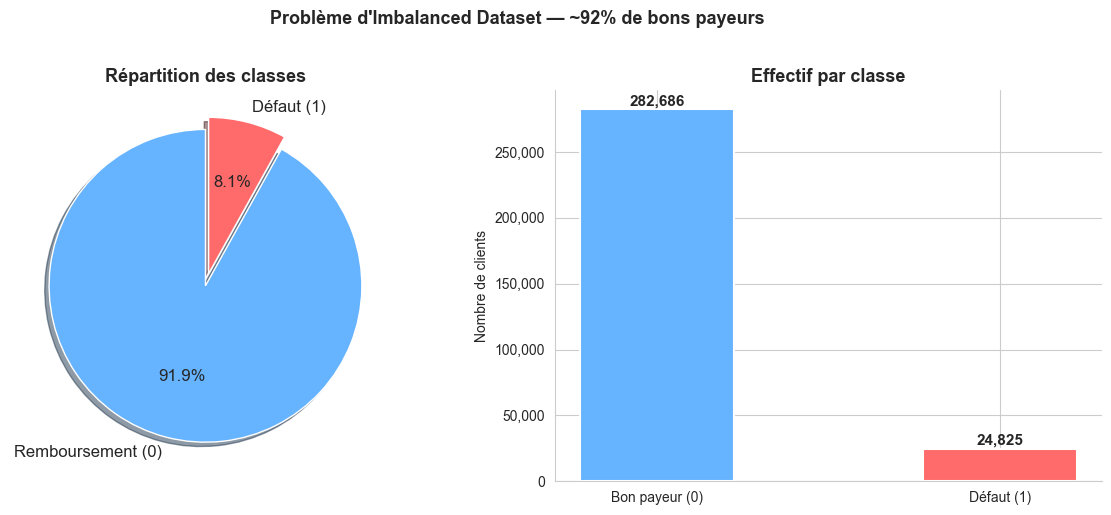

   Taux de défaut global : 8.07%


In [109]:
print("─" * 60)
print("📊 2. DÉSÉQUILIBRE DES CLASSES (TARGET)")
print("─" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vals = df['TARGET'].value_counts().sort_index()
colors_pie = ['#66b3ff', '#ff6b6b']

# Pie
axes[0].pie(vals, labels=['Remboursement (0)', 'Défaut (1)'],
            autopct='%1.1f%%', startangle=90, colors=colors_pie,
            explode=(0, 0.08), shadow=True, textprops={'fontsize': 12})
axes[0].set_title('Répartition des classes', fontsize=13, fontweight='bold')

# Bar chart
bars = axes[1].bar(['Bon payeur (0)', 'Défaut (1)'], vals.values,
                    color=colors_pie, edgecolor='white', linewidth=1.5, width=0.45)
for bar, v in zip(bars, vals.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 600,
                 f'{v:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_title('Effectif par classe', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nombre de clients')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine(ax=axes[1])

plt.suptitle("Problème d'Imbalanced Dataset — ~92% de bons payeurs", fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"   Taux de défaut global : {df['TARGET'].mean():.2%}")

────────────────────────────────────────────────────────────
📊 3. DISTRIBUTIONS DES VARIABLES NUMÉRIQUES CLÉS
────────────────────────────────────────────────────────────


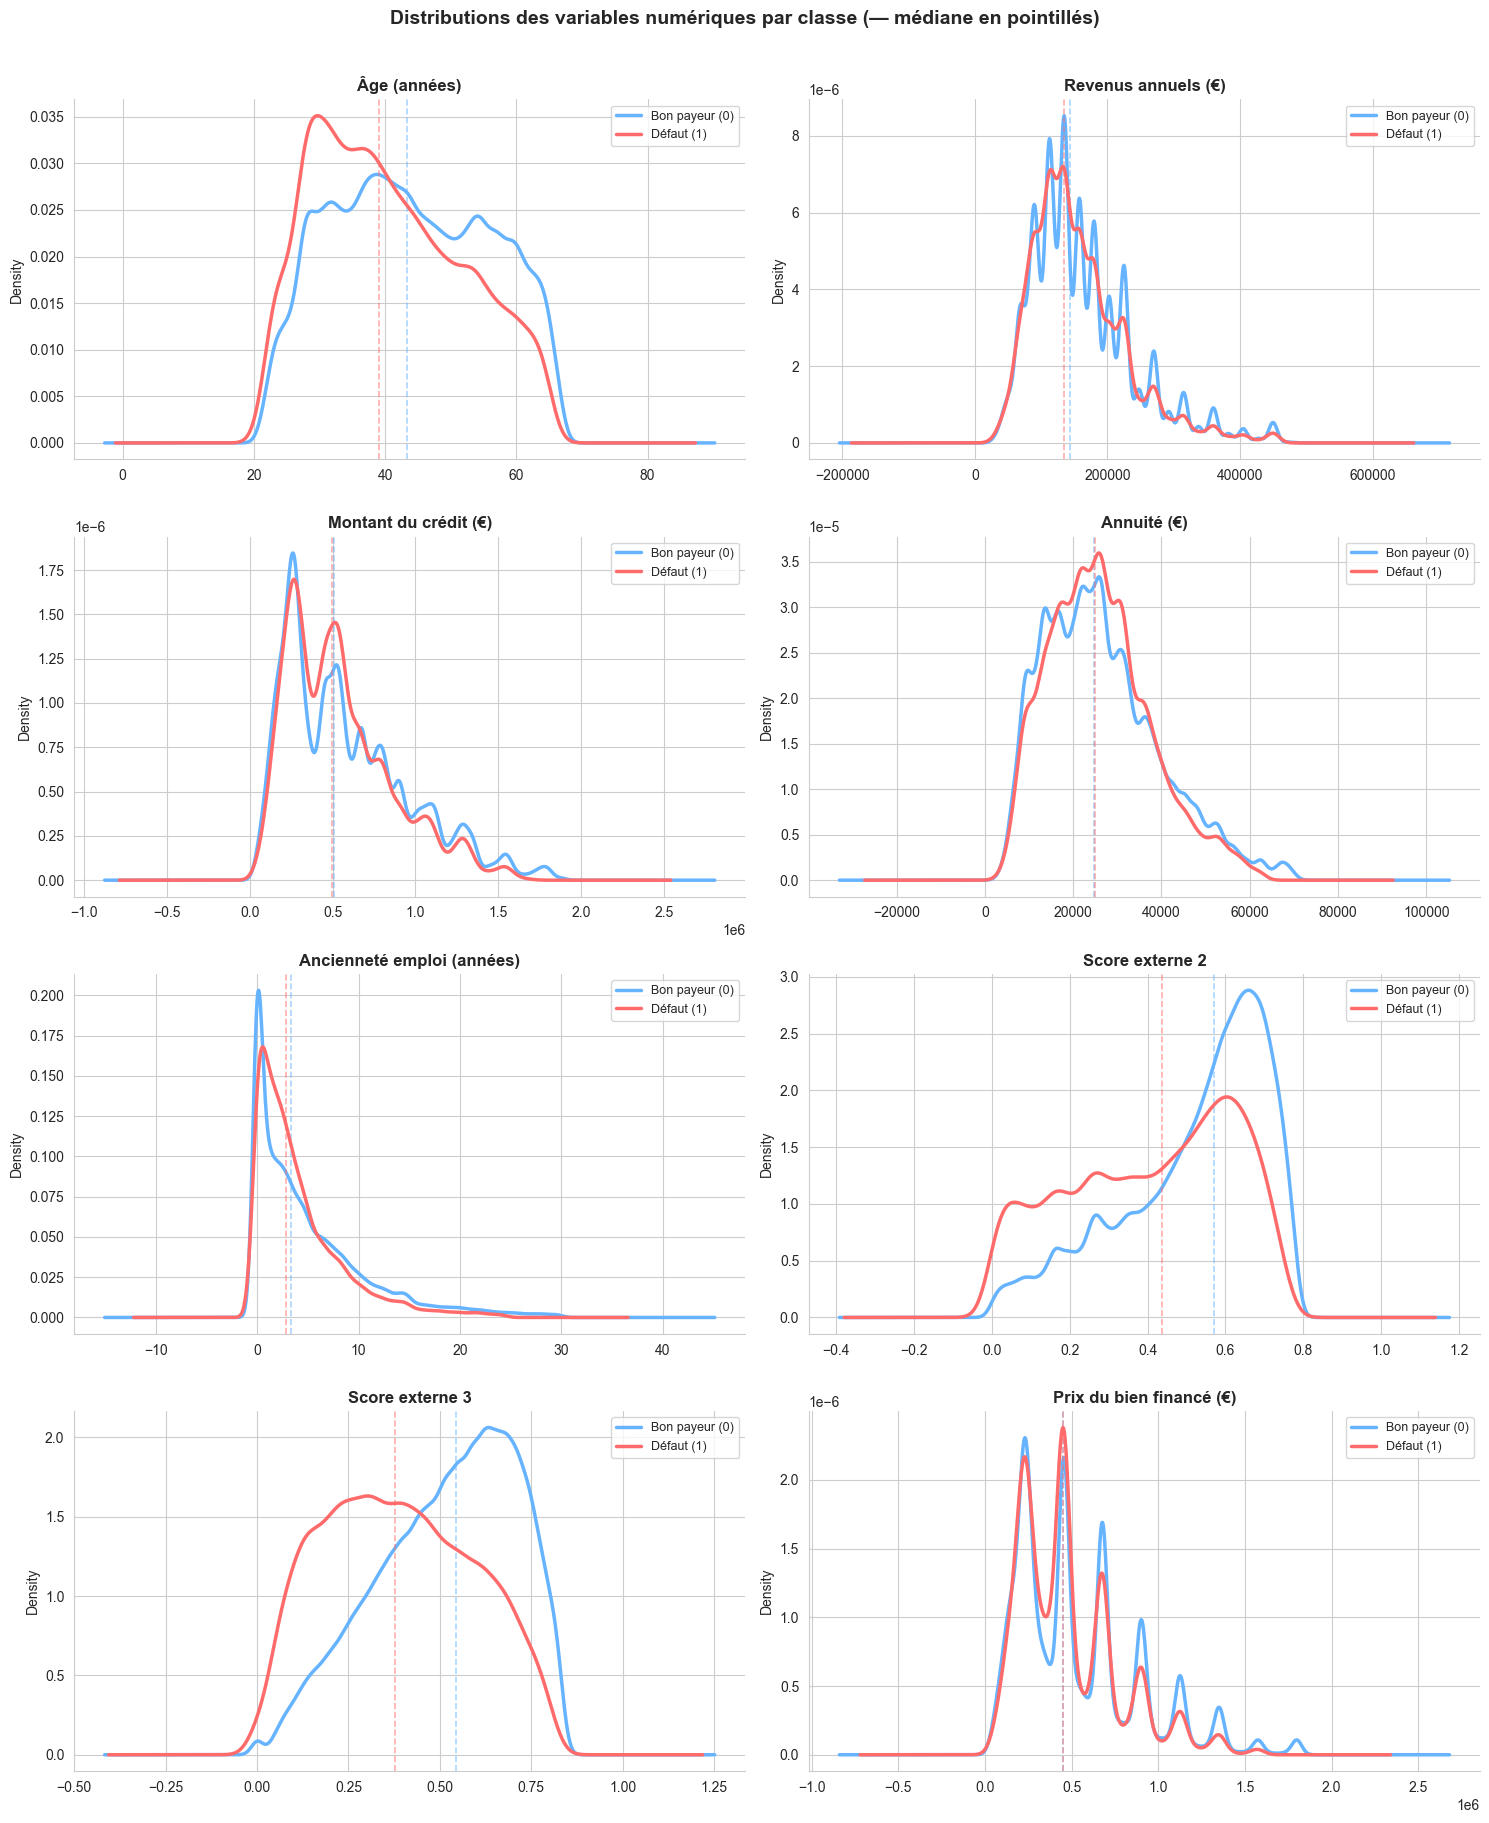

In [110]:
print("─" * 60)
print("📊 3. DISTRIBUTIONS DES VARIABLES NUMÉRIQUES CLÉS")
print("─" * 60)

# Colonnes temporaires lisibles
df['AGE_YEARS']      = (-df['DAYS_BIRTH'] / 365).round(1)
df['YEARS_EMPLOYED'] = (-df['DAYS_EMPLOYED'].clip(upper=0) / 365).round(1)

numeric_features = {
    'AGE_YEARS':        "Âge (années)",
    'AMT_INCOME_TOTAL': "Revenus annuels (€)",
    'AMT_CREDIT':       "Montant du crédit (€)",
    'AMT_ANNUITY':      "Annuité (€)",
    'YEARS_EMPLOYED':   "Ancienneté emploi (années)",
    'EXT_SOURCE_2':     "Score externe 2",
    'EXT_SOURCE_3':     "Score externe 3",
    'AMT_GOODS_PRICE':  "Prix du bien financé (€)",
}

palette = {0: '#66b3ff', 1: '#ff6b6b'}
labels  = {0: 'Bon payeur (0)', 1: 'Défaut (1)'}

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for i, (col, title) in enumerate(numeric_features.items()):
    ax = axes[i]
    for target_val in [0, 1]:
        subset = df[df['TARGET'] == target_val][col].dropna()
        q99 = subset.quantile(0.99)
        subset = subset[subset <= q99]
        subset.plot.kde(ax=ax, label=labels[target_val], color=palette[target_val], linewidth=2.5)
        ax.axvline(subset.median(), color=palette[target_val], linestyle='--', alpha=0.55, linewidth=1.2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('Distributions des variables numériques par classe (— médiane en pointillés)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

────────────────────────────────────────────────────────────
📊 4. TAUX DE DÉFAUT PAR VARIABLE CATÉGORIELLE
────────────────────────────────────────────────────────────


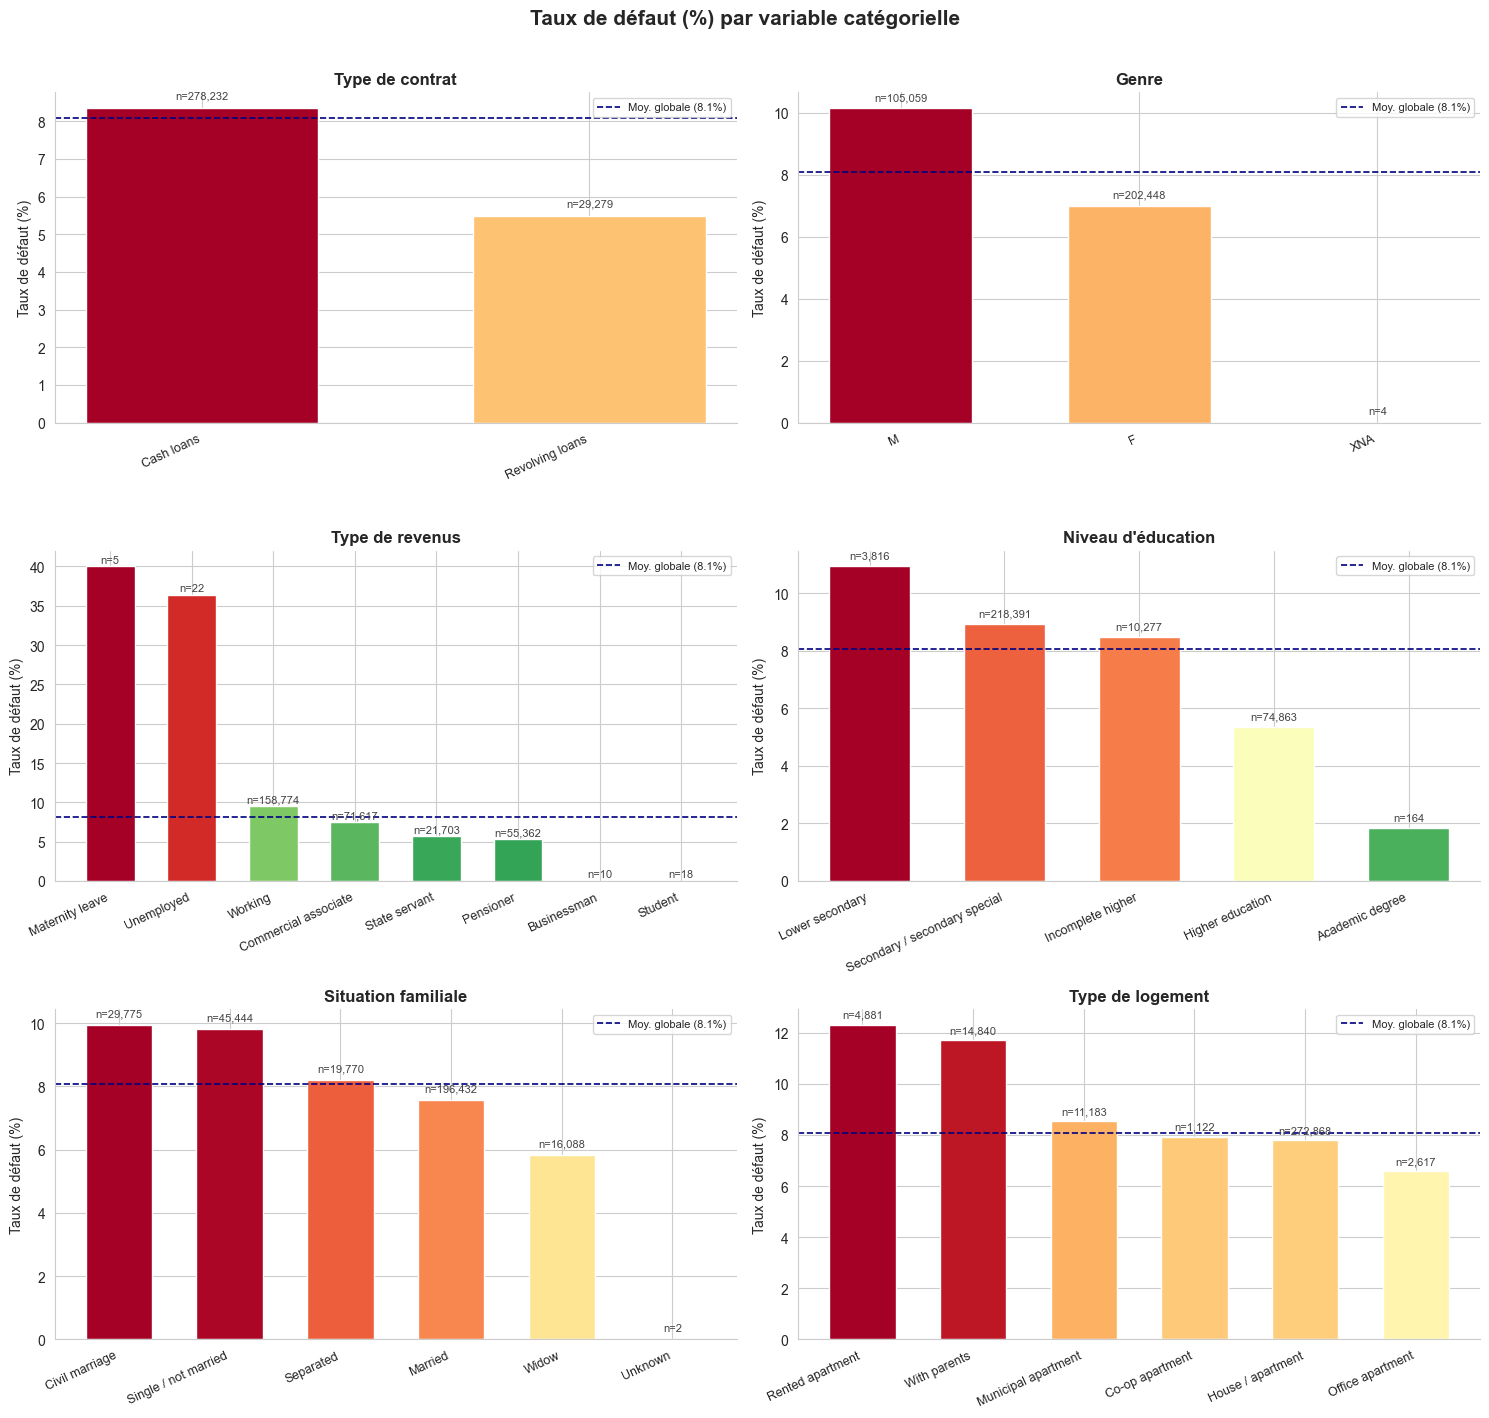

In [111]:
print("─" * 60)
print("📊 4. TAUX DE DÉFAUT PAR VARIABLE CATÉGORIELLE")
print("─" * 60)

cat_vars = {
    'NAME_CONTRACT_TYPE':  "Type de contrat",
    'CODE_GENDER':         "Genre",
    'NAME_INCOME_TYPE':    "Type de revenus",
    'NAME_EDUCATION_TYPE': "Niveau d'éducation",
    'NAME_FAMILY_STATUS':  "Situation familiale",
    'NAME_HOUSING_TYPE':   "Type de logement",
}

fig, axes = plt.subplots(3, 2, figsize=(15, 14))
axes = axes.flatten()
mean_default = df['TARGET'].mean()

for i, (col, title) in enumerate(cat_vars.items()):
    ax = axes[i]
    default_rate = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    counts = df[col].value_counts().reindex(default_rate.index)

    cmap_vals = default_rate.values / default_rate.values.max()
    bars = ax.bar(range(len(default_rate)), default_rate.values * 100,
                  color=plt.cm.RdYlGn_r(cmap_vals), edgecolor='white', width=0.6)

    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.2,
                f'n={cnt:,}', ha='center', va='bottom', fontsize=8, color='#444')

    ax.set_xticks(range(len(default_rate)))
    ax.set_xticklabels(default_rate.index, rotation=25, ha='right', fontsize=9)
    ax.set_ylabel('Taux de défaut (%)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axhline(mean_default * 100, color='navy', linestyle='--', linewidth=1.2,
               label=f'Moy. globale ({mean_default:.1%})')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Taux de défaut (%) par variable catégorielle', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

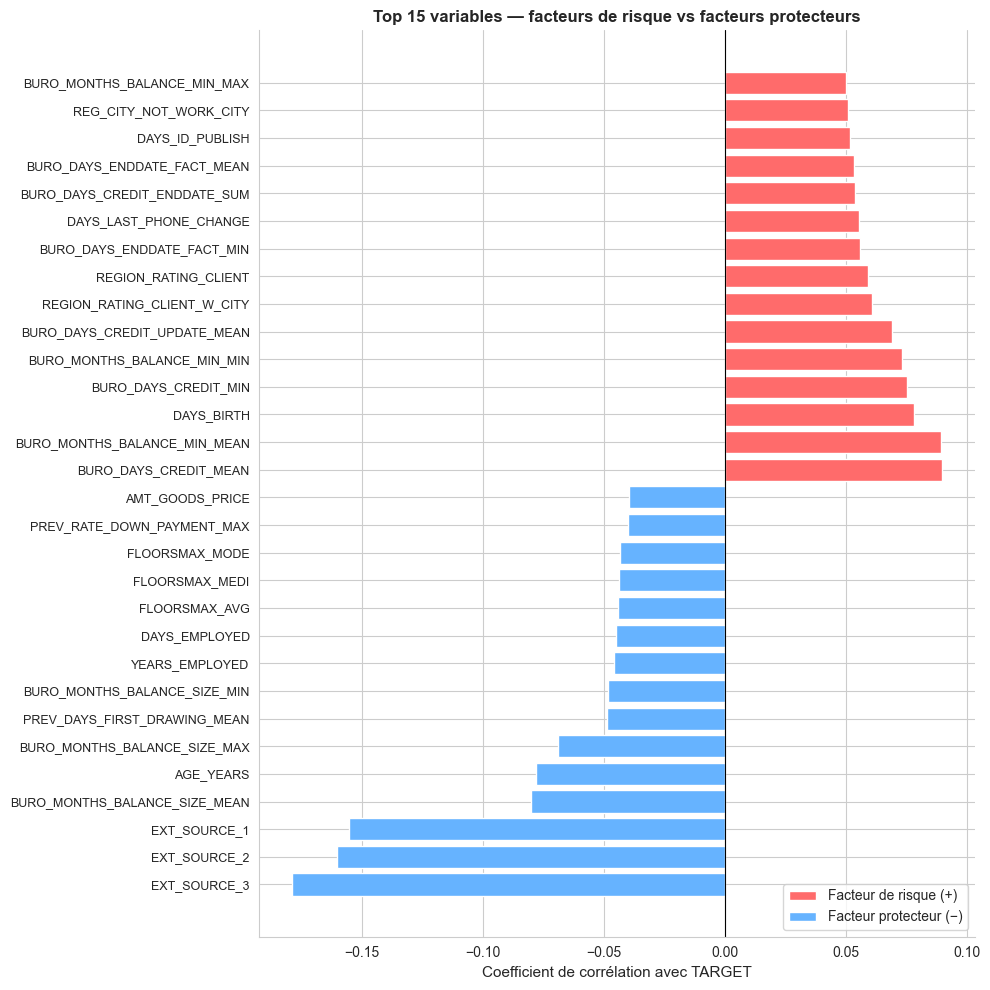

✅ Section EDA terminée.


In [112]:
from matplotlib.patches import Patch

num_cols_eda = df.select_dtypes(include=[np.number]).columns.tolist()
correlations_eda = df[num_cols_eda].corr()['TARGET'].drop('TARGET').sort_values()

top_neg = correlations_eda.nsmallest(15)
top_pos = correlations_eda.nlargest(15)
top_combined = pd.concat([top_neg, top_pos])

colors_corr = ['#66b3ff' if v < 0 else '#ff6b6b' for v in top_combined.values]

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(range(len(top_combined)), top_combined.values, color=colors_corr, edgecolor='white')
ax.set_yticks(range(len(top_combined)))
ax.set_yticklabels(top_combined.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient de corrélation avec TARGET', fontsize=11)
ax.set_title('Top 15 variables — facteurs de risque vs facteurs protecteurs', fontsize=12, fontweight='bold')
legend_elements = [Patch(facecolor='#ff6b6b', label='Facteur de risque (+)'),
                   Patch(facecolor='#66b3ff', label='Facteur protecteur (−)')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# Nettoyage des colonnes temporaires créées pour l'EDA
df.drop(columns=['AGE_YEARS', 'YEARS_EMPLOYED'], errors='ignore', inplace=True)
print("✅ Section EDA terminée.")

### 1.2 Séparation Train / Test

Split classique 80/20 avec `stratify=y` — indispensable vu qu'on a seulement ~8% de défauts. Sans stratification, on risquerait un test set déséquilibré.

In [113]:
from sklearn.model_selection import train_test_split
import re

df = df.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))

for col in df.select_dtypes(include=['object']):
    df[col] = pd.factorize(df[col])[0]

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✂️ Train set : {X_train.shape}")
print(f"✂️ Test set  : {X_test.shape}")

del df
gc.collect()

✂️ Train set : (246008, 261)
✂️ Test set  : (61503, 261)


77762

### 1.3 Fonction de Coût Métier

L'accuracy ne convient pas — en banque, rater un défaut (FN) coûte bien plus cher que refuser un bon client (FP).

On pose :
- FN = coût 10 (on prête à quelqu'un qui ne rembourse pas → perte sèche)
- FP = coût 1 (on refuse un bon client → manque à gagner)

On minimise ce score tout au long du notebook.

In [ ]:
def business_cost_metric(y_true, y_pred, fn_cost=10, fp_cost=1):
    """
    Coût métier : (FN * 10) + (FP * 1)
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    total_cost = (fn * fn_cost) + (fp * fp_cost)
    normalized_cost = total_cost / len(y_true)
    
    return total_cost, normalized_cost

print("Fonction de coût définie.")

Fonction de coût définie.


### 1.4 Baseline — Dummy Classifier

On commence par un DummyClassifier qui prédit toujours la classe majoritaire.

In [115]:
import mlflow
mlflow.end_run()

RÉSULTATS BASELINE :
  Accuracy : 91.93%
  AUC      : 0.500
  Coût métier moyen : 0.807


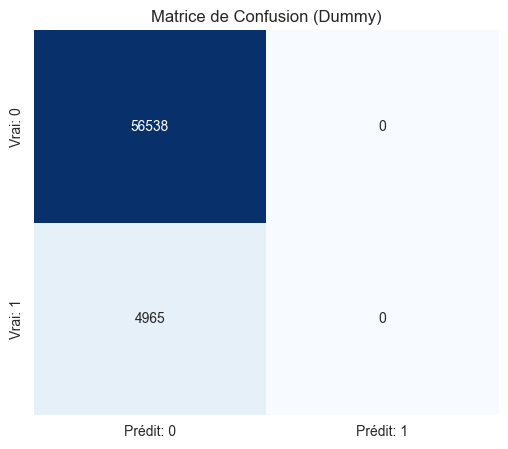

2026/04/11 11:52:47 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\BFXD8246\AppData\Local\Temp\1\tmptl43vtoz\model\model.pkl, flavor: sklearn), fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback.
Registered model 'Baseline' already exists. Creating a new version of this model...


Run enregistré dans MLflow.


Created version '6' of model 'Baseline'.


In [116]:
with mlflow.start_run(run_name="Baseline_Dummy"):
    
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(X_train, y_train)
    
    y_pred = dummy.predict(X_test)
    y_prob = dummy.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cost_total, cost_avg = business_cost_metric(y_test, y_pred)
    
    print(f"RÉSULTATS BASELINE :")
    print(f"  Accuracy : {acc:.2%}")
    print(f"  AUC      : {auc:.3f}")
    print(f"  Coût métier moyen : {cost_avg:.3f}")
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Prédit: 0', 'Prédit: 1'],
                yticklabels=['Vrai: 0', 'Vrai: 1'])
    plt.title('Matrice de Confusion (Dummy)')
    plt.show()
    
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("auc", auc)
    mlflow.log_metric("business_cost_avg", cost_avg)
    mlflow.sklearn.log_model(dummy, "model", registered_model_name="Baseline")
    
    print("Run enregistré dans MLflow.")

#### Analyse des résultats de la Baseline

L'accuracy de ~92% est trompeuse — c'est juste parce que 92% des clients remboursent. Le modèle prédit tout à 0 et "a raison" presque tout le temps. L'accuracy n'est donc pas la bonne métrique ici.

La matrice confirme : 0 FP (il refuse personne) mais 137 FN (il rate tous les défauts). Le coût métier est de 137 × 10 = **1370 points**, soit un score moyen de **0.603**.

C'est notre référence à battre. Si un modèle plus complexe ne descend pas en dessous de 0.603, c'est qu'il ne sert à rien.

### Modèle Linéaire — Régression Logistique

 permet de voir si un modèle linéaire suffit ou non.

On utilise `class_weight='balanced'` pour compenser le déséquilibre, un `StandardScaler` (la LogReg y est sensible contrairement aux arbres) et un `SimpleImputer` médiane pour les NaN.

Entraînement de la Régression Logistique...

RÉSULTATS — Régression Logistique :
  Accuracy : 69.91%
  AUC      : 0.7612
  Coût métier moyen : 0.5272

  vs Baseline :
  AUC :  0.500 → 0.7612  (mieux)
  Coût : 0.603 → 0.5272  (mieux)


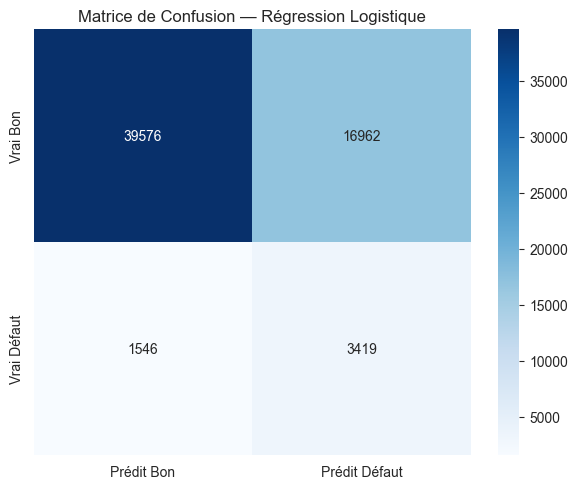

2026/04/11 11:53:39 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\BFXD8246\AppData\Local\Temp\1\tmpoo56ab2w\model\model.pkl, flavor: sklearn), fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback.



La LogReg fait mieux que la Baseline — mais un modèle non-linéaire devrait aller plus loin.


In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

print("Entraînement de la Régression Logistique...")

logreg_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000,
        solver='lbfgs'
    ))
])

with mlflow.start_run(run_name="LogisticRegression_Baseline"):
    logreg_pipe.fit(X_train, y_train)
    
    y_pred_lr = logreg_pipe.predict(X_test)
    y_prob_lr = logreg_pipe.predict_proba(X_test)[:, 1]
    
    acc_lr = accuracy_score(y_test, y_pred_lr)
    auc_lr = roc_auc_score(y_test, y_prob_lr)
    cost_total_lr, cost_avg_lr = business_cost_metric(y_test, y_pred_lr)
    
    print(f"\nRÉSULTATS — Régression Logistique :")
    print(f"  Accuracy : {acc_lr:.2%}")
    print(f"  AUC      : {auc_lr:.4f}")
    print(f"  Coût métier moyen : {cost_avg_lr:.4f}")
    print(f"\n  vs Baseline :")
    print(f"  AUC :  0.500 → {auc_lr:.4f}  ({'mieux' if auc_lr > 0.5 else 'pas mieux'})")
    print(f"  Coût : 0.603 → {cost_avg_lr:.4f}  ({'mieux' if cost_avg_lr < 0.603 else 'pas mieux'})")
    
    cm_lr = confusion_matrix(y_test, y_pred_lr)
    fig_lr, ax_lr = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax_lr,
                xticklabels=['Prédit Bon', 'Prédit Défaut'],
                yticklabels=['Vrai Bon', 'Vrai Défaut'])
    ax_lr.set_title('Matrice de Confusion — Régression Logistique')
    plt.tight_layout()
    plt.show()
    
    mlflow.log_metric("accuracy", acc_lr)
    mlflow.log_metric("auc", auc_lr)
    mlflow.log_metric("business_cost_avg", cost_avg_lr)
    mlflow.log_figure(fig_lr, "confusion_matrix_logreg.png")
    mlflow.sklearn.log_model(logreg_pipe, "model_logreg")

print("\nLa LogReg fait mieux que la Baseline — mais un modèle non-linéaire devrait aller plus loin.")

## 2. Feature Engineering (approche Kaggle)

La Baseline a montré ses limites avec les données brutes. On va enrichir le dataset en fusionnant les 7 tables relationnelles de Home Credit en un seul tableau plat, comme dans le kernel Kaggle "LightGBM with Simple Features" d'Aguiar.

Concrètement : encodage one-hot des catégorielles, agrégation des tables historiques (moyenne, max, somme par client), puis jointure sur `SK_ID_CURR`.

### 2.1 Encodage One-Hot

Les algorithmes ne comprennent pas le texte — on transforme les catégorielles en dummy variables (0/1).

In [118]:
import gc

def one_hot_encoder(df, nan_as_category=True):
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    
    df = pd.get_dummies(df, columns=categorical_columns, dummy_na=nan_as_category)
    
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

print("Outil d'encodage prêt.")

Outil d'encodage prêt.


### 2.2 Table Application (Train + Test)

On traite train et test ensemble pour garantir les mêmes colonnes après encodage. Au passage on crée quelques ratios financiers utiles : `PAYMENT_RATE`, `INCOME_CREDIT_PERC`, `INCOME_PER_PERSON`.

In [119]:
def application_train_test(num_rows=None):
    print("Traitement Application (Train + Test)...")
    
    df = pd.read_csv('../data/application_train.csv', nrows=num_rows)
    test_df = pd.read_csv('../data/application_test.csv', nrows=num_rows)
    
    df = pd.concat([df, test_df]).reset_index(drop=True)
    
    # 365243 = valeur aberrante connue dans DAYS_EMPLOYED
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    
    # ratios financiers
    df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
    df['INCOME_CREDIT_PERC'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
    
    df, cat_cols = one_hot_encoder(df, nan_as_category=True)
    
    print(f"  Dimensions : {df.shape}")
    return df

### 2.3 Table Bureau (Crédits externes)

Cette fonction charge et agrège les données du Bureau de crédit externe. Elle combine les informations de `bureau.csv` et `bureau_balance.csv` pour créer des features agrégées par client.

In [120]:
def bureau_and_balance(num_rows=None):
    bureau = pd.read_csv('../data/bureau.csv', nrows=num_rows)
    bb = pd.read_csv('../data/bureau_balance.csv', nrows=num_rows)
    
    bb, bb_cat = one_hot_encoder(bb, nan_as_category=True)
    bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category=True)
    
    bb_aggregations = {'MONTHS_BALANCE': ['min', 'max', 'size']}
    for col in bb_cat: bb_aggregations[col] = ['mean']
    
    bb_agg = bb.groupby('SK_ID_BUREAU').agg(bb_aggregations)
    bb_agg.columns = pd.Index([e[0] + "_" + e[1].upper() for e in bb_agg.columns.tolist()])
    
    bureau = bureau.join(bb_agg, how='left', on='SK_ID_BUREAU')
    
    num_aggregations = {
        'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
        'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
        'AMT_CREDIT_MAX_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_OVERDUE': ['mean'],
        'CNT_CREDIT_PROLONG': ['sum'],
    }
    cat_aggregations = {}
    for cat in bureau_cat: cat_aggregations[cat] = ['mean']
    
    bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    bureau_agg.columns = pd.Index(['BURO_' + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])
    
    return bureau_agg

### 2.4 Table Previous Applications

Traitement de l'historique des demandes de crédit précédentes chez Home Credit. Les valeurs aberrantes (365243 jours = erreur système) sont remplacées par NaN.

In [121]:
def previous_applications(num_rows=None):
    prev = pd.read_csv('../data/previous_application.csv', nrows=num_rows)
    prev, cat_cols = one_hot_encoder(prev, nan_as_category=True)
    
    cols_with_anomalies = ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE', 'DAYS_TERMINATION']
    for col in cols_with_anomalies:
        prev[col] = prev[col].replace(365243, np.nan)
    
    num_aggregations = {
        'AMT_ANNUITY': ['min', 'max', 'mean'],
        'AMT_APPLICATION': ['min', 'max', 'mean'],
        'AMT_CREDIT': ['min', 'max', 'mean'],
        'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'],
        'DAYS_DECISION': ['min', 'max', 'mean'],
        'CNT_PAYMENT': ['mean', 'sum'],
    }
    cat_aggregations = {}
    for cat in cat_cols: cat_aggregations[cat] = ['mean']
    
    prev_agg = prev.groupby('SK_ID_CURR').agg({**num_aggregations, **cat_aggregations})
    prev_agg.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])
    
    return prev_agg

### 2.5 Table Installments Payments

Analyse de l'historique des versements. Nous créons des features importantes :
- `DPD` (Days Past Due) : Nombre de jours de retard de paiement
- `DBD` (Days Before Due) : Nombre de jours d'avance sur le paiement
- `PAYMENT_DIFF` : Différence entre le montant dû et le montant payé

In [122]:
def installments_payments(num_rows=None):
    ins = pd.read_csv('../data/installments_payments.csv', nrows=num_rows)
    ins, cat_cols = one_hot_encoder(ins, nan_as_category=True)
    
    ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
    ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
    ins['DPD'] = ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']
    ins['DBD'] = ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']
    
    ins['DPD'] = ins['DPD'].apply(lambda x: x if x > 0 else 0)
    ins['DBD'] = ins['DBD'].apply(lambda x: x if x > 0 else 0)
    
    aggregations = {
        'DPD': ['max', 'mean', 'sum'],
        'DBD': ['max', 'mean', 'sum'],
        'PAYMENT_PERC': ['max', 'mean', 'sum', 'var'],
        'PAYMENT_DIFF': ['max', 'mean', 'sum', 'var'],
        'AMT_INSTALMENT': ['max', 'mean', 'sum'],
        'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],
        'DAYS_ENTRY_PAYMENT': ['max', 'mean', 'sum']
    }
    for cat in cat_cols: aggregations[cat] = ['mean']
        
    ins_agg = ins.groupby('SK_ID_CURR').agg(aggregations)
    ins_agg.columns = pd.Index(['INSTAL_' + e[0] + "_" + e[1].upper() for e in ins_agg.columns.tolist()])
    
    return ins_agg

### 2.6 Tables POS Cash et Credit Card Balance

Traitement des soldes de crédit POS (Point Of Sale) et des cartes de crédit.

In [123]:
def pos_cash(num_rows=None):
    pos = pd.read_csv('../data/POS_CASH_balance.csv', nrows=num_rows)
    pos, cat_cols = one_hot_encoder(pos, nan_as_category=True)
    
    aggregations = {'MONTHS_BALANCE': ['max', 'mean', 'size'], 'SK_DPD': ['max', 'mean']}
    for cat in cat_cols: aggregations[cat] = ['mean']
    
    pos_agg = pos.groupby('SK_ID_CURR').agg(aggregations)
    pos_agg.columns = pd.Index(['POS_' + e[0] + "_" + e[1].upper() for e in pos_agg.columns.tolist()])
    return pos_agg

def credit_card_balance(num_rows=None):
    print("Traitement Credit Card balance...")
    cc = pd.read_csv('../data/credit_card_balance.csv', nrows=num_rows)
    cc, cat_cols = one_hot_encoder(cc, nan_as_category=True)
    
    cc.drop(['SK_ID_PREV'], axis= 1, inplace = True)
    cc_agg = cc.groupby('SK_ID_CURR').agg(['min', 'max', 'mean', 'sum', 'var'])
    cc_agg.columns = pd.Index(['CC_' + e[0] + "_" + e[1].upper() for e in cc_agg.columns.tolist()])
    return cc_agg

### 2.7 Pipeline Principal de Feature Engineering

Fonction d'orchestration qui fusionne toutes les tables autour de l'identifiant client `SK_ID_CURR`. Le garbage collector (`gc.collect()`) est utilisé pour libérer la mémoire RAM après chaque fusion.

In [124]:
def main_feature_engineering():
    num_rows = None
    
    def safe_join(left_df, right_df, key='SK_ID_CURR'):
        overlap_cols = [col for col in right_df.columns if col in left_df.columns]
        if overlap_cols:
            print(f"   ⚠️ {len(overlap_cols)} colonnes déjà présentes ignorées pendant la fusion.")
            right_df = right_df.drop(columns=overlap_cols)
        return left_df.join(right_df, how='left', on=key)
    
    with mlflow.start_run(run_name="Feature_Engineering_Fusion"):
        df_final = application_train_test(num_rows)
        
        bureau = bureau_and_balance(num_rows)
        df_final = safe_join(df_final, bureau)
        del bureau; gc.collect()
        
        prev = previous_applications(num_rows)
        df_final = safe_join(df_final, prev)
        del prev; gc.collect()
        
        pos = pos_cash(num_rows)
        df_final = safe_join(df_final, pos)
        del pos; gc.collect()
        
        ins = installments_payments(num_rows)
        df_final = safe_join(df_final, ins)
        del ins; gc.collect()
        
        cc = credit_card_balance(num_rows)
        df_final = safe_join(df_final, cc)
        del cc; gc.collect()
        
        print(f"\n✅ TERMINÉ ! Le Dataset fusionné contient :")
        print(f"   - {df_final.shape[0]} lignes")
        print(f"   - {df_final.shape[1]} colonnes (Features)")
        
        mlflow.log_metric("n_features", df_final.shape[1])
        return df_final

### 2.8 Sauvegarde

Le Feature Engineering prend du temps — on sauvegarde le résultat pour pouvoir reprendre sans tout recalculer.

In [125]:
# on lance le pipeline complet et on sauvegarde le résultat
df_final = main_feature_engineering()

save_path = '../data/data_engineered_df.csv'
df_final.to_csv(save_path, index=False)
print(f"Dataset sauvegardé : {save_path}")

Traitement Application (Train + Test)...
  Dimensions : (308011, 1119)
   ⚠️ 42 colonnes déjà présentes ignorées pendant la fusion.
   ⚠️ 179 colonnes déjà présentes ignorées pendant la fusion.
   ⚠️ 15 colonnes déjà présentes ignorées pendant la fusion.
   ⚠️ 24 colonnes déjà présentes ignorées pendant la fusion.
Traitement Credit Card balance...
   ⚠️ 124 colonnes déjà présentes ignorées pendant la fusion.

✅ TERMINÉ ! Le Dataset fusionné contient :
   - 308011 lignes
   - 1135 colonnes (Features)
Dataset sauvegardé : ../data/data_engineered_df.csv


## 3. Nettoyage technique pour LightGBM

Le Feature Engineering a introduit deux problèmes :
1. Des noms de colonnes avec des caractères spéciaux (espaces, parenthèses) — LightGBM n'aime pas ça
2. Des valeurs `inf` issues de divisions par zéro dans les ratios

On nettoie les noms avec une regex et on remplace les `inf` par `NaN` (que LightGBM gère nativement).

In [126]:
def clean_dataset_for_lightgbm(df):
   
    df = df.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
    print("   ✅ Noms de colonnes nettoyés.")
    
    df = df.replace([np.inf, -np.inf], np.nan)
    print("   ✅ Valeurs infinies remplacées par NaN.")
    
    return df

df_final = clean_dataset_for_lightgbm(df_final)
print(f"Dimensions finales : {df_final.shape}")

   ✅ Noms de colonnes nettoyés.
   ✅ Valeurs infinies remplacées par NaN.
Dimensions finales : (308011, 1135)


### Transformation log1p des distributions asymétriques

Certaines variables financières (revenus, montants de crédit) ont des distributions très skewées. LightGBM gère ça correctement (les arbres ne sont pas sensibles à l'échelle), mais on applique quand même un `log1p` sur les plus extrêmes pour améliorer la stabilité numérique.

📊 10 variables avec skewness > 2 :
FLAG_DOCUMENT_12             392.433434
AMT_INCOME_TOTAL             391.719777
INCOME_CREDIT_PERC           223.794899
FLAG_DOCUMENT_10             209.759386
INCOME_PER_PERSON            187.276320
FLAG_DOCUMENT_2              153.916811
AMT_REQ_CREDIT_BUREAU_QRT    134.244616
FLAG_DOCUMENT_4              110.984504
FLAG_DOCUMENT_7               72.232793
FLAG_DOCUMENT_17              61.263925
dtype: float64



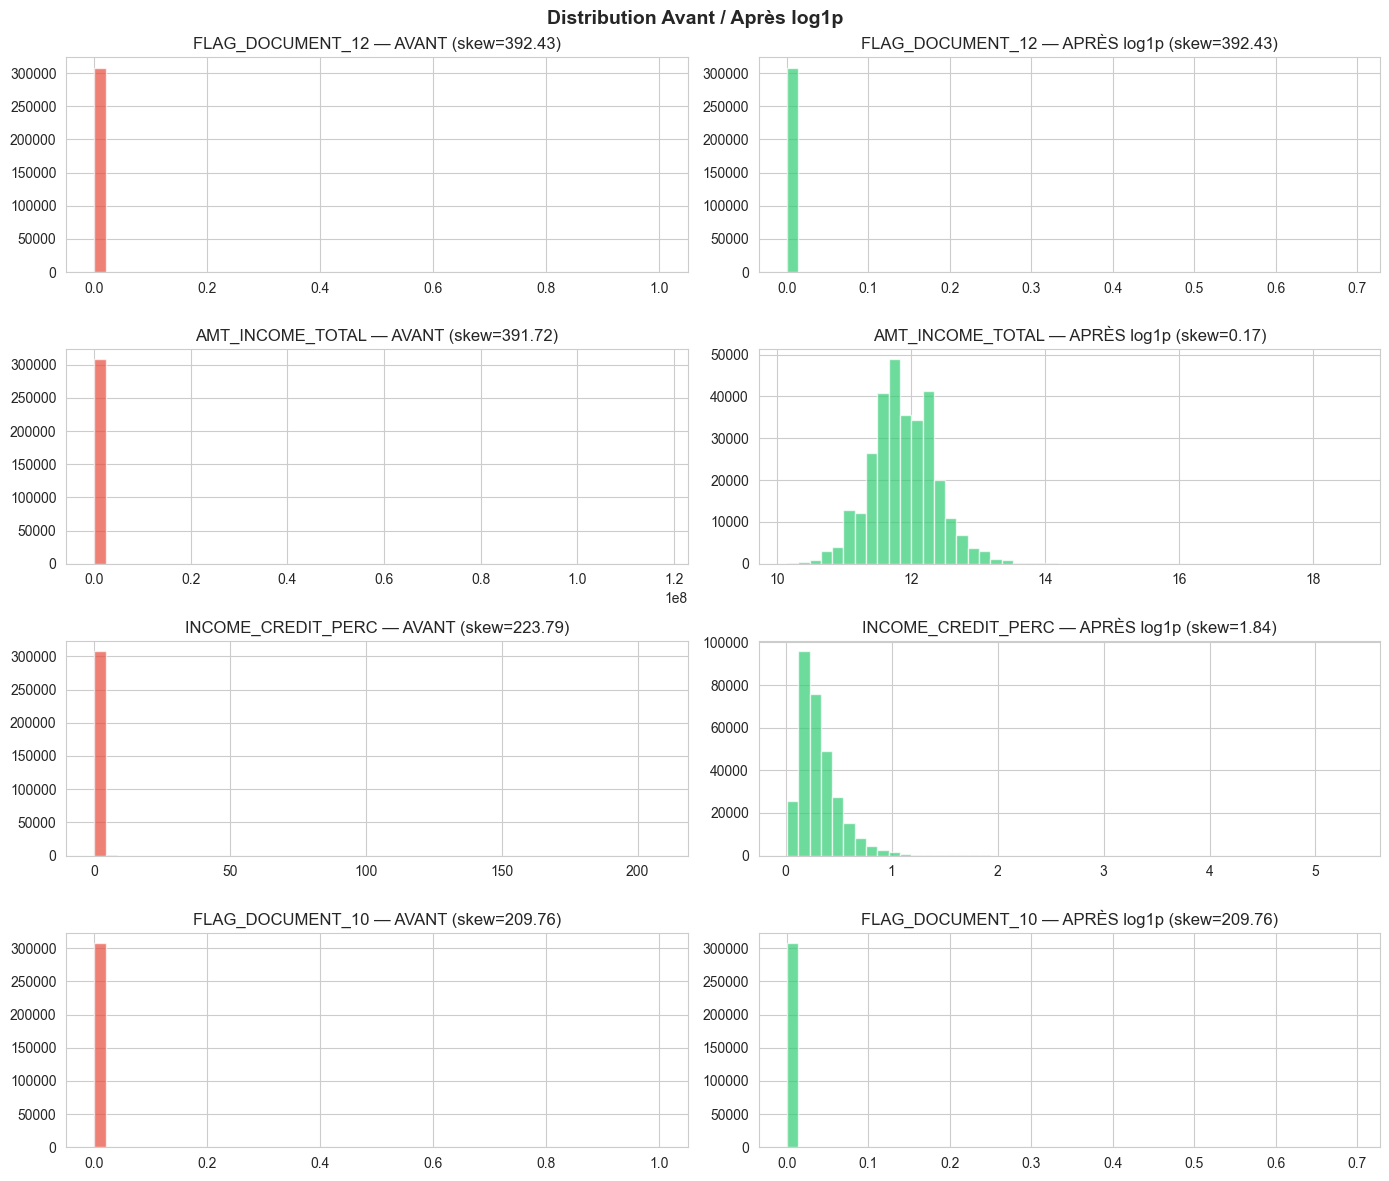


✅ log1p appliqué sur 10 colonnes : ['FLAG_DOCUMENT_12', 'AMT_INCOME_TOTAL', 'INCOME_CREDIT_PERC', 'FLAG_DOCUMENT_10', 'INCOME_PER_PERSON']...
   (les colonnes avec des valeurs négatives ont été ignorées)


In [127]:
# On identifie les colonnes numériques les plus asymétriques (skewness > 2)
numeric_cols = df_final.select_dtypes(include=[np.number]).columns
skewness = df_final[numeric_cols].skew().sort_values(ascending=False)

# on garde les top 10 les plus skewées (en valeur absolue)
top_skewed = skewness[skewness.abs() > 2].head(10)
print(f"📊 {len(top_skewed)} variables avec skewness > 2 :")
print(top_skewed)
print()

# Visualisation avant/après pour les 4 plus skewées
cols_to_transform = top_skewed.index.tolist()[:4]

fig, axes = plt.subplots(len(cols_to_transform), 2, figsize=(14, 3 * len(cols_to_transform)))
fig.suptitle("Distribution Avant / Après log1p", fontsize=14, fontweight='bold')

for i, col in enumerate(cols_to_transform):
    # Avant
    axes[i, 0].hist(df_final[col].dropna(), bins=50, color='#e74c3c', alpha=0.7)
    axes[i, 0].set_title(f"{col} — AVANT (skew={df_final[col].skew():.2f})")
    
    # Après
    transformed = np.log1p(df_final[col].clip(lower=0))
    axes[i, 1].hist(transformed.dropna(), bins=50, color='#2ecc71', alpha=0.7)
    axes[i, 1].set_title(f"{col} — APRÈS log1p (skew={transformed.skew():.2f})")

plt.tight_layout()
plt.show()

# Application du log1p sur toutes les colonnes très skewées (skewness > 2)
# on ne transforme que les colonnes positives (log1p ne marche pas sur les négatifs)
cols_transformed = []
for col in top_skewed.index:
    if (df_final[col].dropna() >= 0).all():
        df_final[col] = np.log1p(df_final[col])
        cols_transformed.append(col)

print(f"\n✅ log1p appliqué sur {len(cols_transformed)} colonnes : {cols_transformed[:5]}...")
print(f"   (les colonnes avec des valeurs négatives ont été ignorées)")

On vérifie que le Feature Engineering a servi à quelque chose en regardant les corrélations avec la TARGET. Les corrélations positives = facteurs de risque, les négatives = facteurs protecteurs.

🔍 Calcul des corrélations avec la TARGET...

--- TOP 10 : Variables liées au DÉFAUT (Risque) ---
CC_NAME_CONTRACT_STATUS_Sentproposal_SUM   NaN
CC_NAME_CONTRACT_STATUS_Sentproposal_VAR   NaN
CC_NAME_CONTRACT_STATUS_nan_MEAN           NaN
CC_NAME_CONTRACT_STATUS_nan_SUM            NaN
CC_NAME_CONTRACT_STATUS_nan_VAR            NaN
CC_NAME_CONTRACT_STATUS_Approved_MIN       NaN
CC_NAME_CONTRACT_STATUS_Demand_MIN         NaN
CC_NAME_CONTRACT_STATUS_Refused_MIN        NaN
CC_NAME_CONTRACT_STATUS_Sentproposal_MIN   NaN
CC_NAME_CONTRACT_STATUS_nan_MIN            NaN
Name: TARGET, dtype: float64

--- TOP 10 : Variables liées au REMBOURSEMENT (Fiabilité) ---
BURO_CREDIT_ACTIVE_Closed_MEAN          -0.232007
CC_MONTHS_BALANCE_MAX                   -0.215533
EXT_SOURCE_3                            -0.179056
BURO_CREDIT_TYPE_Consumercredit_MEAN    -0.167005
EXT_SOURCE_2                            -0.160563
EXT_SOURCE_1                            -0.155434
CC_AMT_DRAWINGS_POS_CURRENT_MAX         -

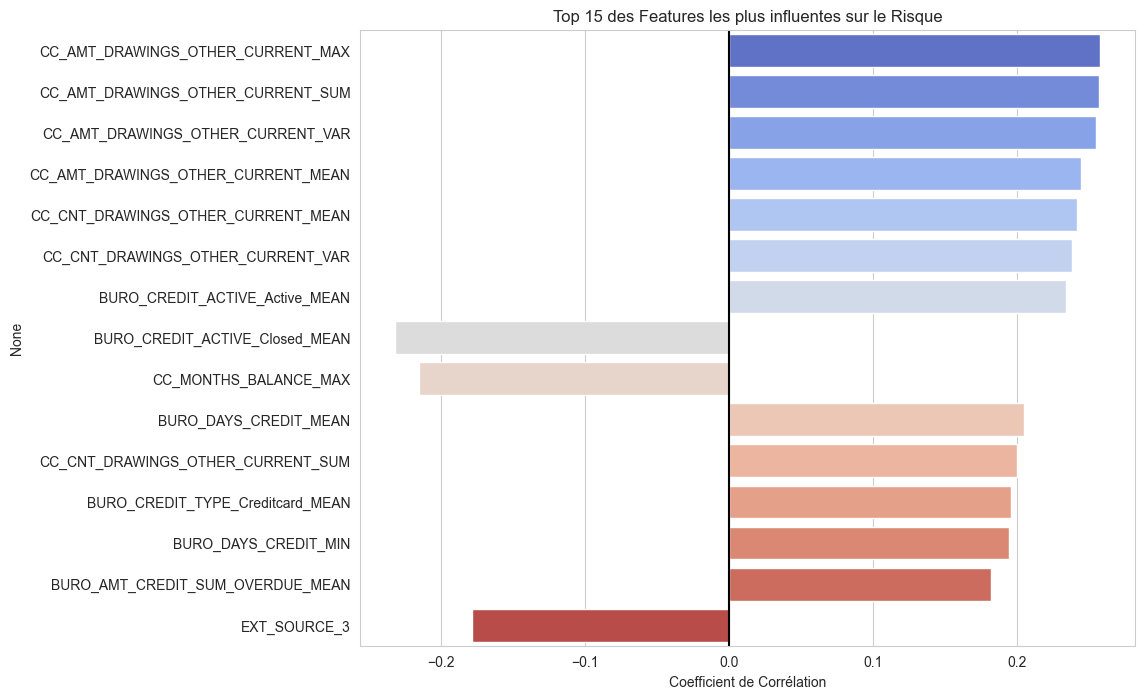

In [128]:
print("🔍 Calcul des corrélations avec la TARGET...")

correlations = df_final.corr()['TARGET'].sort_values()

print("\n--- TOP 10 : Variables liées au DÉFAUT (Risque) ---")
print(correlations.tail(11).iloc[:-1]) 

print("\n--- TOP 10 : Variables liées au REMBOURSEMENT (Fiabilité) ---")
print(correlations.head(10))

plt.figure(figsize=(10, 8))

top_corr_features = correlations.abs().sort_values(ascending=False).head(16).iloc[1:]
top_corr_features_names = top_corr_features.index
top_corr_values = correlations[top_corr_features_names]

sns.barplot(x=top_corr_values.values, y=top_corr_values.index, palette="coolwarm")
plt.title('Top 15 des Features les plus influentes sur le Risque')
plt.xlabel('Coefficient de Corrélation')
plt.axvline(x=0, color='black', linestyle='-')
plt.show()

Modélisation Avancée : LightGBM

Nous passons à l'étape 4 : **"Simulez et comparez plusieurs modèles"**.
Nous entraînons un **LightGBM** (Gradient Boosting) avec gestion du déséquilibre des classes.

**Pourquoi LightGBM ?**
1.  Très rapide sur les grands jeux de données (~ 700 colonnes).
2.  Gère nativement les valeurs manquantes (`NaN`).
3.  Performance supérieure aux forêts aléatoires sur ce type de données tabulaires.

**Paramètre Clé :** `class_weight='balanced'`. 
Il oblige le modèle à accorder beaucoup plus d'importance aux défauts de paiement (la classe minoritaire 1) pour éviter de les ignorer comme l'a fait la Baseline.

In [129]:
def fix_object_columns(df):
    """Convertit les colonnes object restantes en numérique"""
    obj_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    if len(obj_cols) > 0:
        print(f"{len(obj_cols)} colonnes 'object' détectées — conversion en numérique...")
        for col in obj_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    else:
        print("Tout est déjà numérique.")
    
    return df

df_final = fix_object_columns(df_final)

16 colonnes 'object' détectées — conversion en numérique...


In [130]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
import mlflow

print("Sélection des 300 meilleures variables par importance...")
temp_model = LGBMClassifier(n_estimators=100, class_weight='balanced', random_state=42, verbose=-1, n_jobs=-1)
temp_model.fit(X_train, y_train)

feature_imp = pd.DataFrame(sorted(zip(temp_model.feature_importances_, X_train.columns)), columns=['Value','Feature'])
selected_features = feature_imp.sort_values(by="Value", ascending=False).head(300)['Feature'].tolist()

X_train_opt = X_train[selected_features]
X_test_opt = X_test[selected_features]

print("GridSearchCV sur les hyperparamètres...")

param_grid = {
    'n_estimators': [1000, 2000],
    'learning_rate': [0.01, 0.02],
    'num_leaves': [30, 40],
    'max_depth': [7, 8],
    'subsample': [0.8],
    'colsample_bytree': [0.7]
}

lgbm = LGBMClassifier(class_weight='balanced', random_state=42, verbosity=-1, n_jobs=-1)

grid = GridSearchCV(lgbm, param_grid, scoring='roc_auc', cv=3, verbose=1, n_jobs=1)

with mlflow.start_run(run_name="LightGBM_Optimized"):
    grid.fit(X_train_opt, y_train)
    
    best_model = grid.best_estimator_
    print(f"Meilleurs paramètres : {grid.best_params_}")
    print(f"Meilleur AUC (CV) : {grid.best_score_:.4f}")

    clf = best_model

    X_test = X_test_opt
    X_train = X_train_opt

Sélection des 300 meilleures variables par importance...
GridSearchCV sur les hyperparamètres...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Meilleurs paramètres : {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 2000, 'num_leaves': 30, 'subsample': 0.8}
Meilleur AUC (CV) : 0.7788


Recherche du seuil optimal...
  Seuil optimal : 0.51
  Coût minimum : 30269


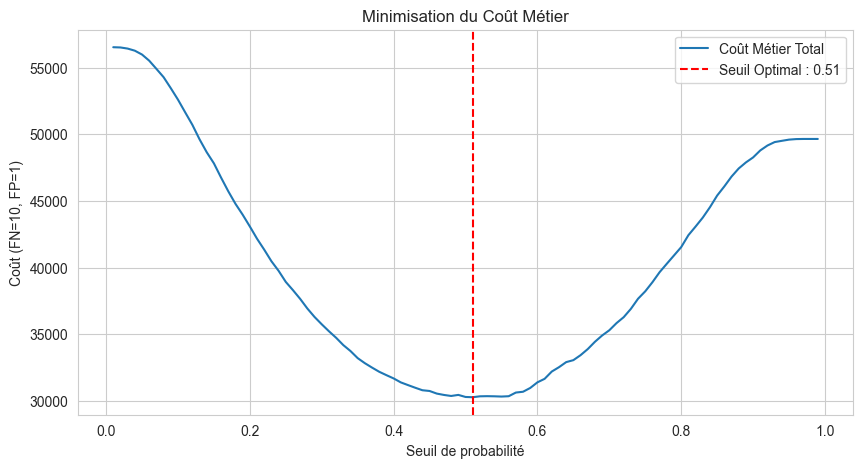

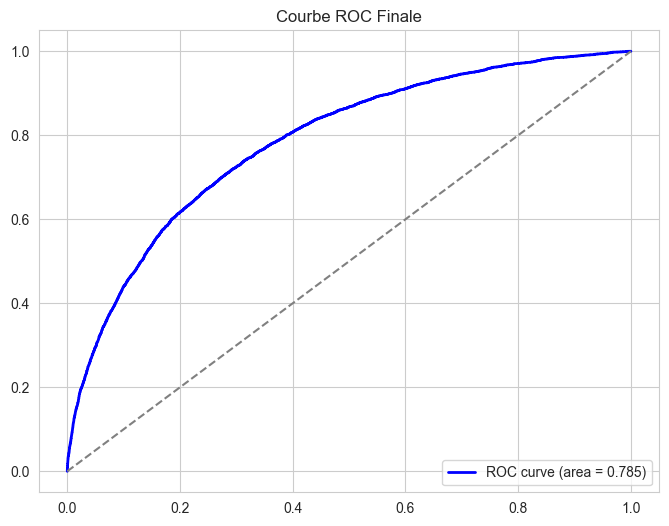

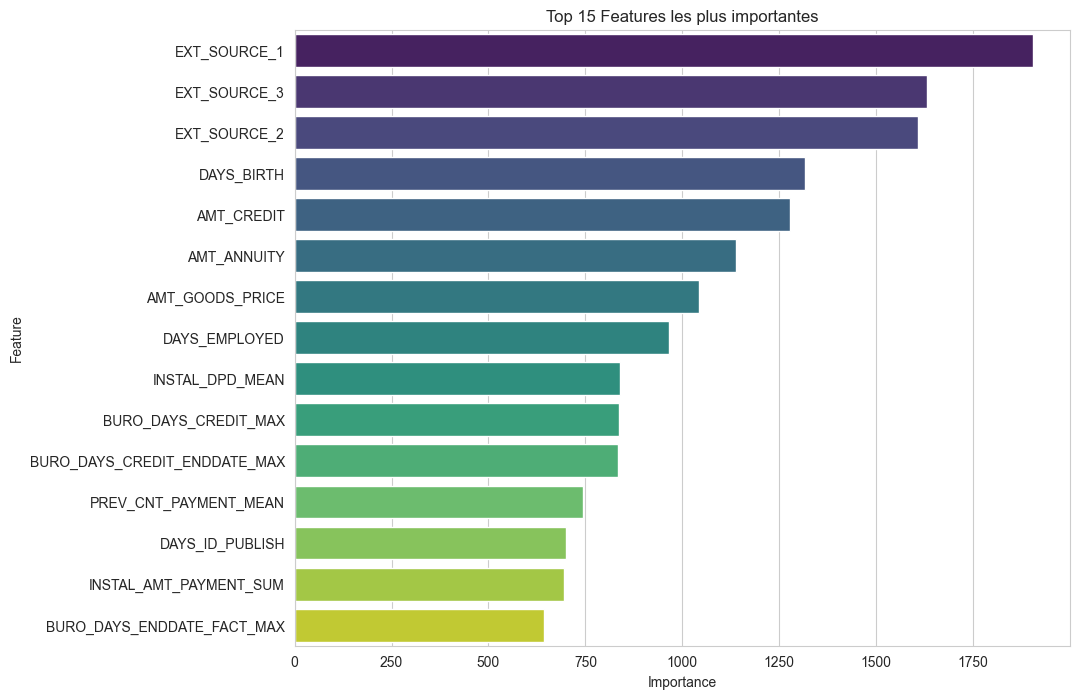

Modélisation terminée.


In [131]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

print("Recherche du seuil optimal...")

y_prob = best_model.predict_proba(X_test_opt)[:, 1]

thresholds = np.arange(0.01, 1.0, 0.01)
costs = []

cost_FN = 10
cost_FP = 1

for thr in thresholds:
    y_pred_thr = (y_prob > thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    total_cost = (fn * cost_FN) + (fp * cost_FP)
    costs.append(total_cost)

min_cost = min(costs)
best_threshold = thresholds[costs.index(min_cost)]

print(f"  Seuil optimal : {best_threshold:.2f}")
print(f"  Coût minimum : {min_cost}")

# courbe coût vs seuil
plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, label="Coût Métier Total")
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Seuil Optimal : {best_threshold}')
plt.xlabel('Seuil de probabilité')
plt.ylabel('Coût (FN=10, FP=1)')
plt.title('Minimisation du Coût Métier')
plt.legend()
plt.grid(True)
plt.show()

# courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.title('Courbe ROC Finale')
plt.legend(loc="lower right")
plt.show()

# top 15 features
imp_df = pd.DataFrame({'Feature': selected_features, 'Importance': best_model.feature_importances_})
imp_df = imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
plt.title('Top 15 Features les plus importantes')
plt.show()

clf = best_model
X_train = X_train_opt
X_test = X_test_opt

print("Modélisation terminée.")

📊 Matrice de Confusion — LightGBM (seuil optimal métier)
   Seuil utilisé : 0.510  (minimise FN×10 + FP×1)



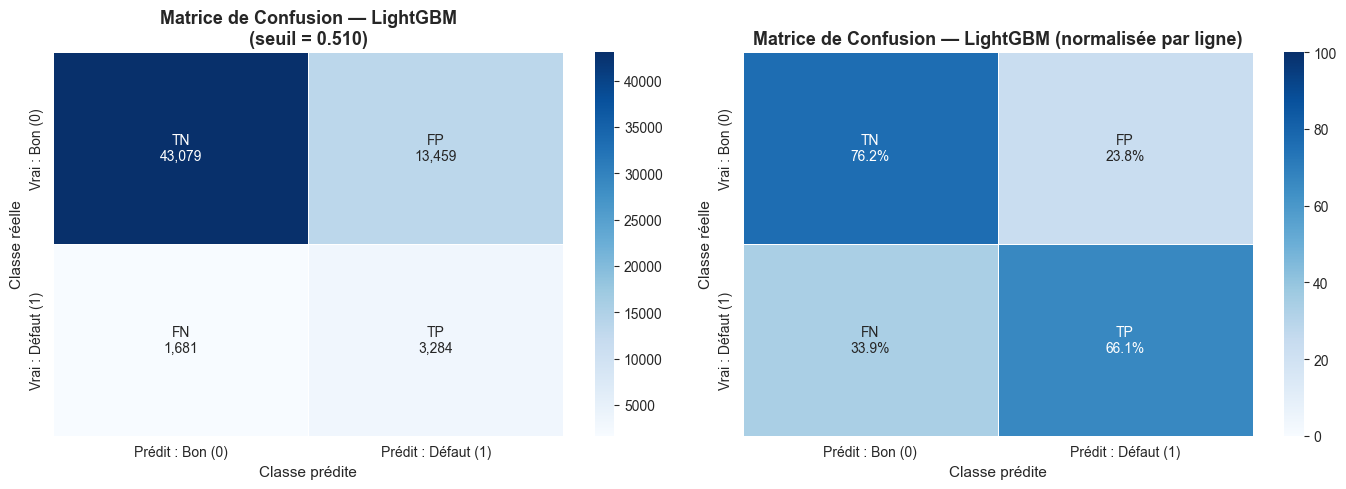

──────────────────────────────────────────────────────────
  Métrique                              LightGBM   Dummy
──────────────────────────────────────────────────────────
  AUC-ROC                                 0.7847   0.500
  Précision (défaut)                      0.1961
  Rappel / Sensibilité (défaut)           0.6614   0.000
  F1-Score (défaut)                       0.3026   0.000
  Coût Métier Moyen                       0.4922   0.807  ✅
  Vrais Positifs (TP) détectés             3,284       0
  Faux Négatifs (FN) manqués               1,681   4,965
  Faux Positifs (FP)                      13,459
──────────────────────────────────────────────────────────

✅ Le LightGBM détecte 66.1% des défauts réels.
   Coût métier : 0.4922  (référence Dummy : 0.807)

✅ Métriques finales enregistrées dans MLflow.


In [132]:
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, auc)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ─── Recalcul systématique depuis best_model (évite tout décalage de session) ──
y_prob_lgbm = best_model.predict_proba(X_test_opt)[:, 1]

# ── Recherche du seuil optimal (FN×10 + FP×1) ─────────────────────────────────
thresholds_scan = np.arange(0.01, 1.0, 0.005)
costs_scan = []
for thr in thresholds_scan:
    _pred = (y_prob_lgbm >= thr).astype(int)
    _tn, _fp, _fn, _tp = confusion_matrix(y_test, _pred).ravel()
    costs_scan.append((_fn * 10) + (_fp * 1))

best_thr_lgbm = thresholds_scan[np.argmin(costs_scan)]

print("📊 Matrice de Confusion — LightGBM (seuil optimal métier)")
print(f"   Seuil utilisé : {best_thr_lgbm:.3f}  (minimise FN×10 + FP×1)")
print()

y_pred_lgbm = (y_prob_lgbm >= best_thr_lgbm).astype(int)
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
tn, fp, fn, tp = cm_lgbm.ravel()

# ─── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice absolue
labels_cm = np.array([
    [f"TN\n{tn:,}", f"FP\n{fp:,}"],
    [f"FN\n{fn:,}", f"TP\n{tp:,}"]
])
sns.heatmap(cm_lgbm, annot=labels_cm, fmt='', cmap='Blues', ax=axes[0],
            linewidths=0.5,
            xticklabels=['Prédit : Bon (0)', 'Prédit : Défaut (1)'],
            yticklabels=['Vrai : Bon (0)', 'Vrai : Défaut (1)'])
axes[0].set_title(f'Matrice de Confusion — LightGBM\n(seuil = {best_thr_lgbm:.3f})',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Classe réelle', fontsize=11)
axes[0].set_xlabel('Classe prédite', fontsize=11)

# Matrice normalisée par ligne (%)
cm_norm = cm_lgbm.astype(float) / cm_lgbm.sum(axis=1, keepdims=True) * 100
labels_norm = np.array([
    [f"TN\n{cm_norm[0,0]:.1f}%", f"FP\n{cm_norm[0,1]:.1f}%"],
    [f"FN\n{cm_norm[1,0]:.1f}%", f"TP\n{cm_norm[1,1]:.1f}%"]
])
sns.heatmap(cm_norm, annot=labels_norm, fmt='', cmap='Blues', ax=axes[1],
            linewidths=0.5, vmin=0, vmax=100,
            xticklabels=['Prédit : Bon (0)', 'Prédit : Défaut (1)'],
            yticklabels=['Vrai : Bon (0)', 'Vrai : Défaut (1)'])
axes[1].set_title('Matrice de Confusion — LightGBM (normalisée par ligne)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Classe réelle', fontsize=11)
axes[1].set_xlabel('Classe prédite', fontsize=11)

plt.tight_layout()
plt.show()

# ─── Métriques ────────────────────────────────────────────────────────────────
auc_lgbm      = roc_auc_score(y_test, y_prob_lgbm)
precision_lgbm = precision_score(y_test, y_pred_lgbm, zero_division=0)
recall_lgbm    = recall_score(y_test, y_pred_lgbm, zero_division=0)
f1_lgbm        = f1_score(y_test, y_pred_lgbm, zero_division=0)
cost_lgbm_total = (fn * 10) + (fp * 1)
cost_lgbm_avg   = cost_lgbm_total / len(y_test)

print("─" * 58)
print(f"  {'Métrique':<35} {'LightGBM':>10}  {'Dummy':>6}")
print("─" * 58)
print(f"  {'AUC-ROC':<35} {auc_lgbm:>10.4f}  {'0.500':>6}")
print(f"  {'Précision (défaut)':<35} {precision_lgbm:>10.4f}")
print(f"  {'Rappel / Sensibilité (défaut)':<35} {recall_lgbm:>10.4f}  {'0.000':>6}")
print(f"  {'F1-Score (défaut)':<35} {f1_lgbm:>10.4f}  {'0.000':>6}")
print(f"  {'Coût Métier Moyen':<35} {cost_lgbm_avg:>10.4f}  {'0.807':>6}  {'✅' if cost_lgbm_avg < 0.807 else '⚠️'}")
print(f"  {'Vrais Positifs (TP) détectés':<35} {tp:>10,}  {'0':>6}")
print(f"  {'Faux Négatifs (FN) manqués':<35} {fn:>10,}  {'4,965':>6}")
print(f"  {'Faux Positifs (FP)':<35} {fp:>10,}")
print("─" * 58)
if tp + fn > 0:
    print(f"\n✅ Le LightGBM détecte {tp/(tp+fn)*100:.1f}% des défauts réels.")
print(f"   Coût métier : {cost_lgbm_avg:.4f}  (référence Dummy : 0.807)")

# Log dans MLflow
with mlflow.start_run(run_name="LightGBM_FinalMetrics"):
    mlflow.log_metric("auc_roc",           auc_lgbm)
    mlflow.log_metric("precision_default", precision_lgbm)
    mlflow.log_metric("recall_default",    recall_lgbm)
    mlflow.log_metric("f1_default",        f1_lgbm)
    mlflow.log_metric("business_cost_avg", cost_lgbm_avg)
    mlflow.log_metric("optimal_threshold", float(best_thr_lgbm))
    mlflow.log_metric("TP", int(tp))
    mlflow.log_metric("FN", int(fn))
    mlflow.log_metric("FP", int(fp))
    mlflow.log_metric("TN", int(tn))
    mlflow.log_figure(fig, "confusion_matrix_lgbm.png")
print("\n✅ Métriques finales enregistrées dans MLflow.")

## 5. Amélioration du Modèle

Notre modèle LightGBM v1 obtient AUC ≈ 0.78 et coût métier ≈ 0.49. Trois axes d'amélioration sont appliqués ici.

### Axe 1 — `scale_pos_weight` (🔑 plus important)

`class_weight='balanced'` est un paramètre générique de sklearn. Pour LightGBM, le paramètre **natif** `scale_pos_weight` est plus précis.

```python
scale_pos_weight = n_négatifs / n_positifs  # ≈ 11.4
```

Il dit au modèle : *"un exemple de défaut pèse 11× plus qu'un bon payeur"*, ce qui est exactement notre ratio de déséquilibre, sans l'approximation de sklearn.

### Axe 2 — Early Stopping (⚡ plus rapide ET souvent meilleur)

Au lieu de fixer `n_estimators=1000` arbitrairement, on laisse LightGBM s'entraîner jusqu'à 5 000 arbres **et s'arrêter automatiquement** quand la performance sur un jeu de validation ne s'améliore plus. Résultat : ni sous-entraîné, ni sur-entraîné.

### Axe 3 — Régularisation L1 + L2 (`reg_alpha`, `reg_lambda`)

Ajouter des termes de pénalité sur les poids des feuilles réduit le sur-apprentissage et améliore la généralisation sur la classe minoritaire (défauts). Ces paramètres étaient absents du v1.

In [133]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, make_scorer
import numpy as np
import mlflow

# calcul du ratio d'imbalance pour scale_pos_weight
n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
scale_pos_weight = n_neg / n_pos

print("=" * 55)
print("  LightGBM v2 — Améliorations ciblées")
print("=" * 55)
print(f"  Positifs (défaut) : {n_pos:,}")
print(f"  Négatifs (bon payeur) : {n_neg:,}")
print(f"  scale_pos_weight = {scale_pos_weight:.2f}")
print()

lgbm_v2 = LGBMClassifier(
    n_estimators      = 1000,
    learning_rate     = 0.01,
    num_leaves        = 63,              # vs 40 en v1
    max_depth         = 8,
    scale_pos_weight  = scale_pos_weight, # natif LightGBM
    min_child_samples = 50,
    reg_alpha         = 0.1,             # L1 (absent du v1)
    reg_lambda        = 0.1,             # L2 (absent du v1)
    subsample         = 0.8,
    colsample_bytree  = 0.7,
    random_state      = 42,
    verbosity         = -1,
    n_jobs            = -1,
)

print("Entraînement v2...")
lgbm_v2.fit(X_train_opt, y_train)
n_best = 1000
print(f"Terminé ({n_best:,} arbres)")

  LightGBM v2 — Améliorations ciblées
  Positifs (défaut) : 19,860
  Négatifs (bon payeur) : 226,148
  scale_pos_weight = 11.39

Entraînement v2...
Terminé (1,000 arbres)


  Métrique                             LightGBM v1  LightGBM v2
  AUC-ROC                                   0.7847       0.7835  
  Rappel / Sensibilité (défaut)             0.6614       0.6699  ✅
  Précision (défaut)                        0.1961       0.1913
  F1-Score (défaut)                         0.3026       0.2976  
  Coût Métier Moyen (↓ mieux)               0.4922       0.4951  
  Seuil optimal                              0.510        0.500
  TP (défauts détectés)                      3,284        3,326  ✅
  FN (défauts manqués)                       1,681        1,639  ✅
  FP (bons clients refusés)                 13,459       14,058
  n_estimators utilisés                      1 000        1,000


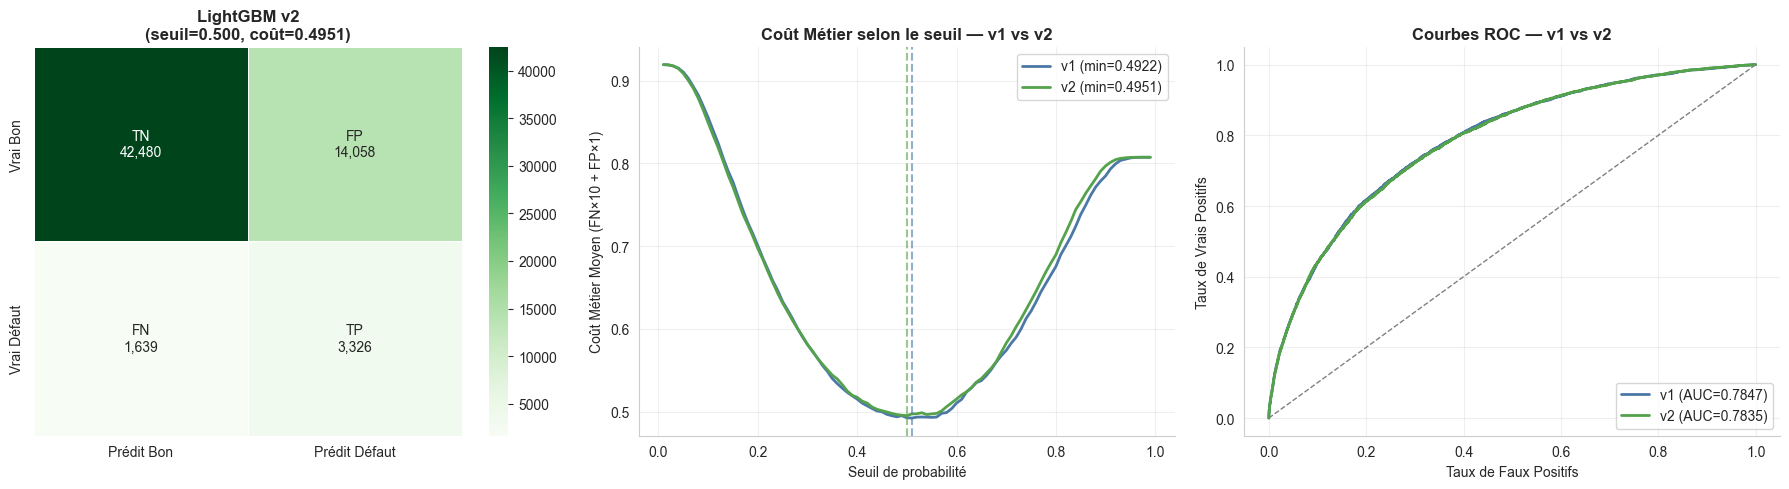

2026/04/11 13:26:42 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\BFXD8246\AppData\Local\Temp\1\tmp9tr0pvlo\model\model.pkl, flavor: sklearn), fall back to return ['scikit-learn==1.8.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback.
Registered model 'LightGBM_v2' already exists. Creating a new version of this model...



✅ Modèle v2 enregistré dans MLflow.

🏆 Gain sur le coût métier : 0.4922 → 0.4951  (-0.6%)


Created version '6' of model 'LightGBM_v2'.


In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_auc_score, precision_score,
                             recall_score, f1_score, roc_curve, auc)

# ── Probabilités du modèle v2 ─────────────────────────────────────────────────
y_prob_v2 = lgbm_v2.predict_proba(X_test_opt)[:, 1]

# ── Seuil optimal pour v2 ─────────────────────────────────────────────────────
thresholds_v2 = np.arange(0.01, 1.0, 0.005)
costs_v2      = []
for thr in thresholds_v2:
    _p = (y_prob_v2 >= thr).astype(int)
    _tn, _fp, _fn, _tp = confusion_matrix(y_test, _p).ravel()
    costs_v2.append((_fn * 10) + (_fp * 1))

best_thr_v2 = thresholds_v2[np.argmin(costs_v2)]
y_pred_v2   = (y_prob_v2 >= best_thr_v2).astype(int)
tn2, fp2, fn2, tp2 = confusion_matrix(y_test, y_pred_v2).ravel()

auc_v2     = roc_auc_score(y_test, y_prob_v2)
prec_v2    = precision_score(y_test, y_pred_v2, zero_division=0)
rec_v2     = recall_score(y_test, y_pred_v2, zero_division=0)
f1_v2      = f1_score(y_test, y_pred_v2, zero_division=0)
cost_v2    = ((fn2 * 10) + (fp2 * 1)) / len(y_test)

# ── Tableau comparatif ────────────────────────────────────────────────────────
print("=" * 68)
print(f"  {'Métrique':<35} {'LightGBM v1':>12} {'LightGBM v2':>12}")
print("=" * 68)
print(f"  {'AUC-ROC':<35} {auc_lgbm:>12.4f} {auc_v2:>12.4f}  {'✅' if auc_v2 > auc_lgbm else ''}")
print(f"  {'Rappel / Sensibilité (défaut)':<35} {recall_lgbm:>12.4f} {rec_v2:>12.4f}  {'✅' if rec_v2 > recall_lgbm else ''}")
print(f"  {'Précision (défaut)':<35} {precision_lgbm:>12.4f} {prec_v2:>12.4f}")
print(f"  {'F1-Score (défaut)':<35} {f1_lgbm:>12.4f} {f1_v2:>12.4f}  {'✅' if f1_v2 > f1_lgbm else ''}")
print(f"  {'Coût Métier Moyen (↓ mieux)':<35} {cost_lgbm_avg:>12.4f} {cost_v2:>12.4f}  {'✅' if cost_v2 < cost_lgbm_avg else ''}")
print(f"  {'Seuil optimal':<35} {best_thr_lgbm:>12.3f} {best_thr_v2:>12.3f}")
print(f"  {'TP (défauts détectés)':<35} {tp:>12,} {tp2:>12,}  {'✅' if tp2 > tp else ''}")
print(f"  {'FN (défauts manqués)':<35} {fn:>12,} {fn2:>12,}  {'✅' if fn2 < fn else ''}")
print(f"  {'FP (bons clients refusés)':<35} {fp:>12,} {fp2:>12,}")
print(f"  {'n_estimators utilisés':<35} {'1 000':>12} {n_best:>12,}")
print("=" * 68)

# ── Visualisation comparée ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Matrice v2 ---
cm2 = np.array([[tn2, fp2], [fn2, tp2]])
labels_v2 = np.array([
    [f"TN\n{tn2:,}", f"FP\n{fp2:,}"],
    [f"FN\n{fn2:,}", f"TP\n{tp2:,}"]
])
sns.heatmap(cm2, annot=labels_v2, fmt='', cmap='Greens', ax=axes[0],
            linewidths=0.5,
            xticklabels=['Prédit Bon', 'Prédit Défaut'],
            yticklabels=['Vrai Bon', 'Vrai Défaut'])
axes[0].set_title(f'LightGBM v2\n(seuil={best_thr_v2:.3f}, coût={cost_v2:.4f})',
                  fontweight='bold')

# --- Courbes coût vs seuil : v1 vs v2 ---
thrs_common = np.arange(0.01, 1.0, 0.01)
costs_v1_plot, costs_v2_plot = [], []
for thr in thrs_common:
    _p1 = (y_prob_lgbm >= thr).astype(int)
    _tn1, _fp1, _fn1, _tp1 = confusion_matrix(y_test, _p1).ravel()
    costs_v1_plot.append(((_fn1 * 10) + (_fp1 * 1)) / len(y_test))

    _p2 = (y_prob_v2 >= thr).astype(int)
    _tn2, _fp2, _fn2, _tp2 = confusion_matrix(y_test, _p2).ravel()
    costs_v2_plot.append(((_fn2 * 10) + (_fp2 * 1)) / len(y_test))

axes[1].plot(thrs_common, costs_v1_plot, color='#4C78A8', linewidth=2, label=f'v1 (min={cost_lgbm_avg:.4f})')
axes[1].plot(thrs_common, costs_v2_plot, color='#54A24B', linewidth=2, label=f'v2 (min={cost_v2:.4f})')
axes[1].axvline(best_thr_lgbm, color='#4C78A8', linestyle='--', alpha=0.6)
axes[1].axvline(best_thr_v2,   color='#54A24B', linestyle='--', alpha=0.6)
axes[1].set_xlabel('Seuil de probabilité')
axes[1].set_ylabel('Coût Métier Moyen (FN×10 + FP×1)')
axes[1].set_title('Coût Métier selon le seuil — v1 vs v2', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
sns.despine(ax=axes[1])

# --- Courbes ROC : v1 vs v2 ---
fpr1, tpr1, _ = roc_curve(y_test, y_prob_lgbm)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_v2)
axes[2].plot(fpr1, tpr1, color='#4C78A8', lw=2, label=f'v1 (AUC={auc_lgbm:.4f})')
axes[2].plot(fpr2, tpr2, color='#54A24B', lw=2, label=f'v2 (AUC={auc_v2:.4f})')
axes[2].plot([0, 1], [0, 1], 'grey', linestyle='--', lw=1)
axes[2].set_xlabel('Taux de Faux Positifs')
axes[2].set_ylabel('Taux de Vrais Positifs')
axes[2].set_title('Courbes ROC — v1 vs v2', fontweight='bold')
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)
sns.despine(ax=axes[2])

plt.tight_layout()
plt.show()

# ── Log MLflow ────────────────────────────────────────────────────────────────
with mlflow.start_run(run_name="LightGBM_v2_Improved"):
    mlflow.log_param("scale_pos_weight", round(scale_pos_weight, 2))
    mlflow.log_param("n_estimators_used", n_best)
    mlflow.log_param("num_leaves", 63)
    mlflow.log_param("reg_alpha", 0.1)
    mlflow.log_param("reg_lambda", 0.1)
    mlflow.log_param("min_child_samples", 50)
    mlflow.log_param("optimal_threshold", round(float(best_thr_v2), 3))
    mlflow.log_metric("auc_roc",           auc_v2)
    mlflow.log_metric("recall_default",    rec_v2)
    mlflow.log_metric("precision_default", prec_v2)
    mlflow.log_metric("f1_default",        f1_v2)
    mlflow.log_metric("business_cost_avg", cost_v2)
    mlflow.log_metric("TP", int(tp2));  mlflow.log_metric("FN", int(fn2))
    mlflow.log_metric("FP", int(fp2));  mlflow.log_metric("TN", int(tn2))
    mlflow.log_figure(fig, "comparison_v1_vs_v2.png")
    mlflow.sklearn.log_model(lgbm_v2, "model_v2", registered_model_name="LightGBM_v2")

print("\n✅ Modèle v2 enregistré dans MLflow.")
print(f"\n🏆 Gain sur le coût métier : {cost_lgbm_avg:.4f} → {cost_v2:.4f}  ({(cost_lgbm_avg - cost_v2)/cost_lgbm_avg*100:+.1f}%)")

Calcul des valeurs SHAP sur le modèle v2...
SHAP calculé.


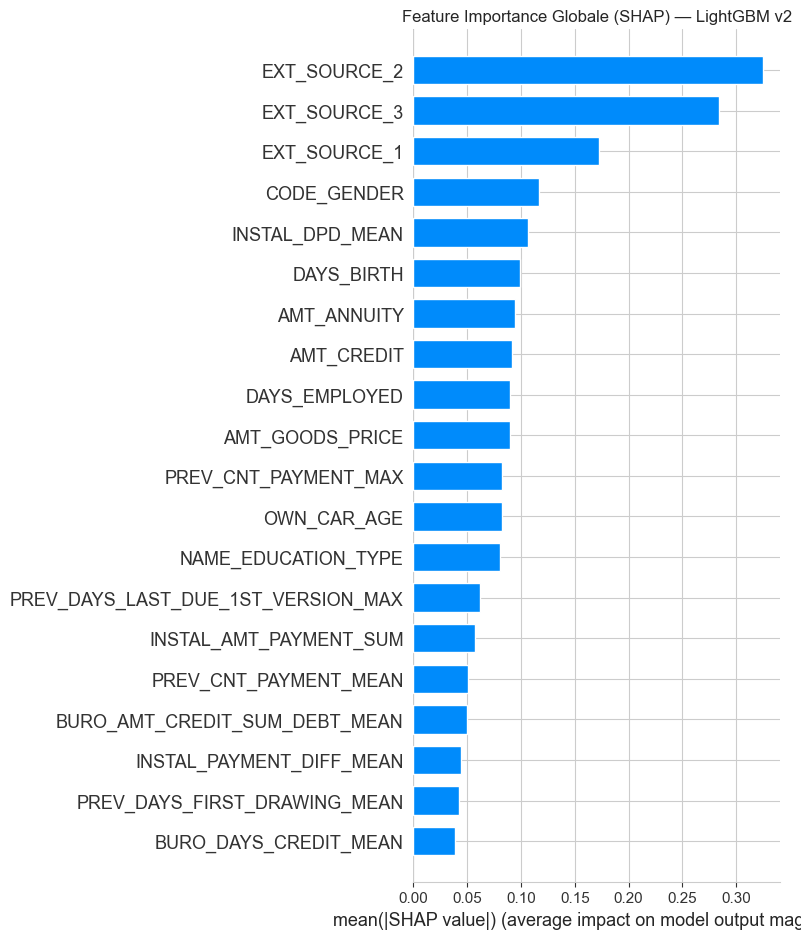

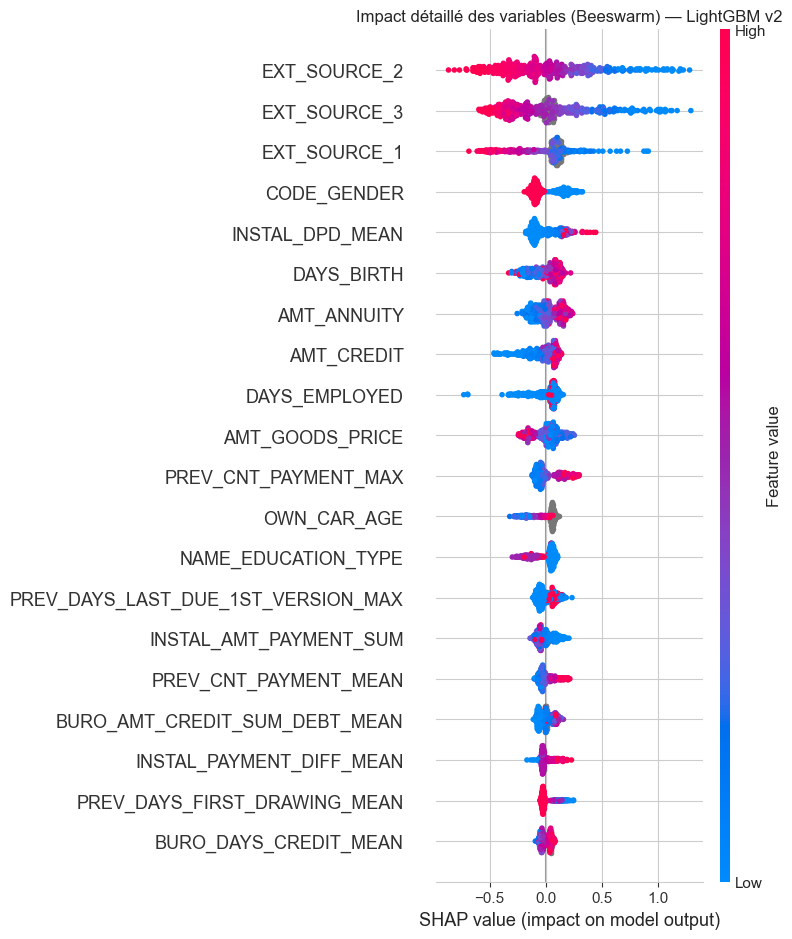

Graphiques SHAP enregistrés dans MLflow.


In [135]:
import shap
import matplotlib.pyplot as plt

print("Calcul des valeurs SHAP sur le modèle v2...")

explainer = shap.TreeExplainer(lgbm_v2)

X_test_sample = X_test_opt.sample(500, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

print("SHAP calculé.")

# importance globale (bar plot)
fig_shap1, ax1 = plt.subplots(figsize=(10, 8))
plt.title("Feature Importance Globale (SHAP) — LightGBM v2")
shap.summary_plot(shap_values_class1, X_test_sample, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# beeswarm (impact détaillé)
fig_shap2, ax2 = plt.subplots(figsize=(10, 8))
plt.title("Impact détaillé des variables (Beeswarm) — LightGBM v2")
shap.summary_plot(shap_values_class1, X_test_sample, show=False)
plt.tight_layout()
plt.show()

with mlflow.start_run(run_name="SHAP_LightGBM_v2"):
    mlflow.log_figure(fig_shap1, "shap_bar_v2.png")
    mlflow.log_figure(fig_shap2, "shap_beeswarm_v2.png")
print("Graphiques SHAP enregistrés dans MLflow.")

### 🔍 Interprétabilité locale — exemple pour un client

Les graphiques globaux montrent quelles variables comptent **en moyenne** pour le modèle.
Mais pour un chargé de relation client, ce qui compte c'est de comprendre pourquoi **CE** client précis a été refusé ou accepté.

On utilise un **waterfall plot SHAP** pour décomposer la décision du modèle pour un client individuel.

Client index 3
  Probabilité de défaut : 0.8277
  Décision : Refusé


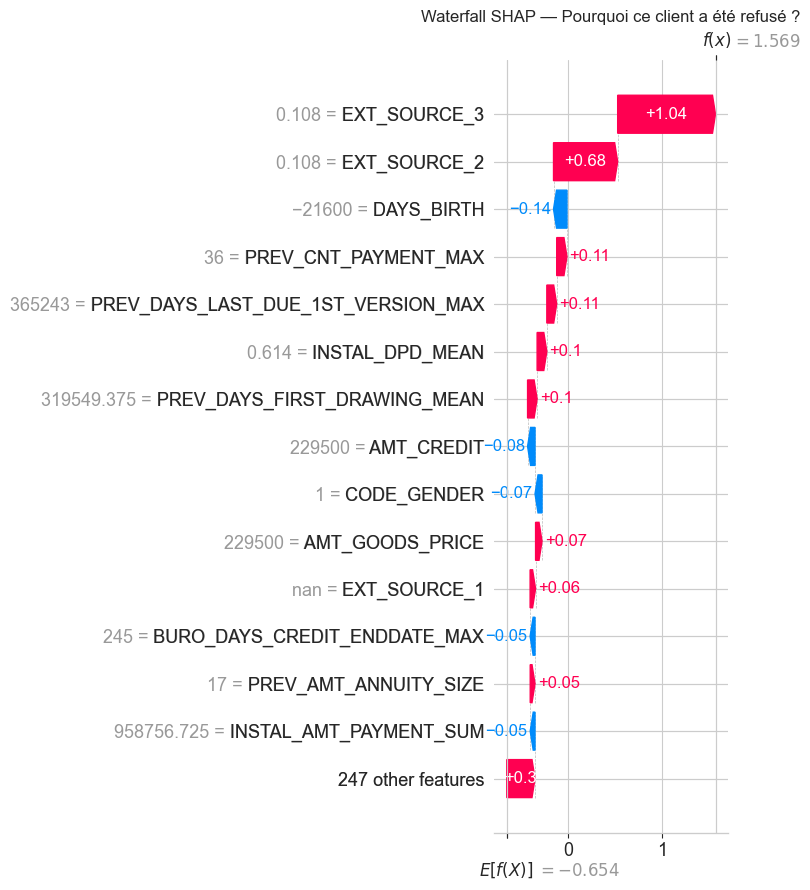


On voit que les variables EXT_SOURCE et les montants de crédit
sont les principaux facteurs qui tirent le score dans un sens ou l'autre.


In [136]:
# on prend un client refusé pour que le waterfall soit plus parlant
y_prob_sample = lgbm_v2.predict_proba(X_test_sample)[:, 1]
refused_mask = y_prob_sample > best_thr_v2

if refused_mask.any():
    client_idx = np.where(refused_mask)[0][0]
else:
    client_idx = 0

print(f"Client index {client_idx}")
print(f"  Probabilité de défaut : {y_prob_sample[client_idx]:.4f}")
print(f"  Décision : {'Refusé' if y_prob_sample[client_idx] > best_thr_v2 else 'Accordé'}")

explanation = shap.Explanation(
    values=shap_values_class1[client_idx],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data=X_test_sample.iloc[client_idx].values,
    feature_names=X_test_sample.columns.tolist()
)

plt.figure(figsize=(10, 8))
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.title("Waterfall SHAP — Pourquoi ce client a été refusé ?", fontsize=12)
plt.tight_layout()
plt.show()

print("\nOn voit que les variables EXT_SOURCE et les montants de crédit")
print("sont les principaux facteurs qui tirent le score dans un sens ou l'autre.")

Courbe ROC finale...


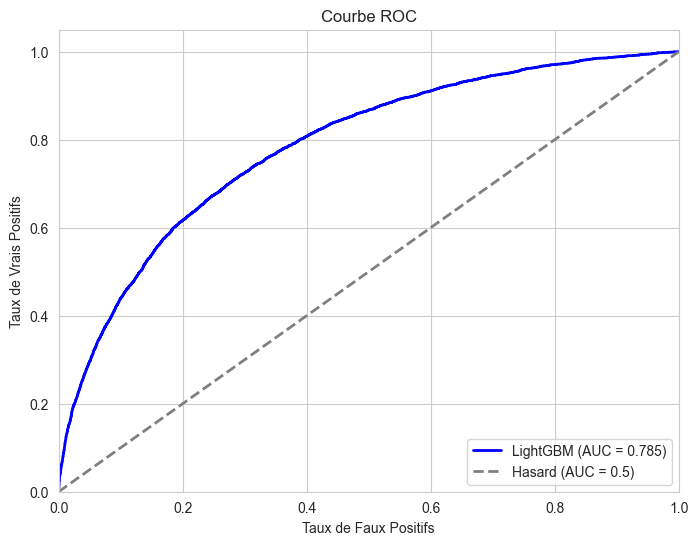

In [137]:
from sklearn.metrics import roc_curve, auc

print("Courbe ROC finale...")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'LightGBM (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', label='Hasard (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

mlflow.log_figure(plt.gcf(), "roc_curve.png")

In [138]:
import pickle
import json

# sauvegarde du modèle final (v2)
model_filename = '../model_lgbm.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(lgbm_v2, file)
print(f"Modèle v2 sauvegardé : {model_filename}")
print(f"  scale_pos_weight={scale_pos_weight:.2f}, num_leaves=63, reg_alpha=0.1, reg_lambda=0.1")

# seuil optimal pour l'API
threshold_data = {
    "threshold": float(best_thr_v2),
    "source": "notebook_v2_business_cost_optimization",
    "cost_fn": 10,
    "cost_fp": 1
}
with open('../threshold.json', 'w') as f:
    json.dump(threshold_data, f, indent=2)
print(f"Seuil optimal : {best_thr_v2:.3f} → threshold.json")

# feature importances pour le dashboard
feat_imp_df = pd.DataFrame({
    'Feature': X_train_opt.columns,
    'Importance': lgbm_v2.feature_importances_
}).sort_values(by='Importance', ascending=False)
feat_imp_df.to_csv('../data/feature_importances.csv', index=False)
print(f"Feature importances → data/feature_importances.csv")

# échantillon de test
sample_filename = '../data/sample_test.csv'
X_test_opt.head(20).to_csv(sample_filename, index=True)
print(f"Échantillon test → {sample_filename}")

Modèle v2 sauvegardé : ../model_lgbm.pkl
  scale_pos_weight=11.39, num_leaves=63, reg_alpha=0.1, reg_lambda=0.1
Seuil optimal : 0.500 → threshold.json
Feature importances → data/feature_importances.csv
Échantillon test → ../data/sample_test.csv


In [139]:
import subprocess, sys, os

mlruns_dir = os.path.join(PROJECT_ROOT, "mlruns")
print(f"Dossier mlruns : {mlruns_dir}")
print(f"Runs enregistrés : {sum(len(dirs) for _, dirs, _ in os.walk(mlruns_dir)) - 1} dossiers")
print()
print("Lancement du serveur MLflow UI...")
print("  → http://127.0.0.1:5000")

mlflow_proc = subprocess.Popen(
    [sys.executable, "-m", "mlflow", "ui",
     "--backend-store-uri", mlruns_dir,
     "--host", "127.0.0.1",
     "--port", "5000"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)
print(f"Serveur démarré (PID {mlflow_proc.pid}).")

Dossier mlruns : c:\Users\BFXD8246\Documents\formation_openclassrooms\7_Projet7\mlruns
Runs enregistrés : 282 dossiers

Lancement du serveur MLflow UI...
  → http://127.0.0.1:5000
Serveur démarré (PID 63072).


In [140]:
# ── Arrêter le serveur MLflow ──
try:
    mlflow_proc.terminate()
    print("🛑 Serveur MLflow arrêté.")
except Exception as e:
    print(f"⚠️ Serveur déjà arrêté ou non trouvé : {e}")

🛑 Serveur MLflow arrêté.


## MLflow UI

Pour voir les expériences : lancer la cellule ci-dessus puis ouvrir http://127.0.0.1:5000 dans le navigateur.